### WIDS Equity Classification
#### Exploratory Data Analysis (EDA)

In [2]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading dataset
data = pd.read_csv('raw_dataset.csv')

In [4]:
data.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,CMIE Expr,CMIE Expr.1,CMIE Expr.2,CMIE Expr.3,CMIE Expr.4,CMIE Expr.5,...,CMIE Expr.17,CMIE Expr.18,CMIE Expr.19,CMIE Expr.20,CMIE Expr.21,CMIE Expr.22,CMIE Expr.23,CMIE Expr.24,CMIE Expr.25,CMIE Expr.26
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,BSE,BSE,BSE,BSE,BSE,BSE,BSE,BSE,BSE/NSE,BSE/NSE
1,NaN,NaN,NaN,NaN,Quarterly Interim Standalone,Quarterly Interim Standalone,Quarterly Interim Standalone,Quarterly Interim Standalone,Quarterly Interim Standalone,Quarterly Interim Standalone,...,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ,Finance S / Interim SQ
2,NaN,NaN,NaN,NaN,Date,Rs. Crore,Rs. Crore,Rs. Crore,Rs. Crore,Rs. Crore,...,Date,Indian Rupee,Nos.,Rs. Crore,Indian Rupee,Times,Nos.,Rs. Crore,Times,No.
3,NaN,NaN,NaN,NaN,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023,...,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023,Jan 2023
4,Company Name,Industry group,ISIN code,NSE symbol,Date,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of fin...",...,Date,Closing Price,Shares Outstanding,Market Capitalisation,EPS,P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
5,3M India Ltd.,"Plastic furniture, floorings & miscellaneous i...",INE470A01017,3MINDIA,31-12-2022,943.41,932.22,-12.09,818.55,562.38,...,31-01-2023,23145.65,11265070,26073.736745,346.895314,66.722291,267,24891.636745,52.52,0.815759
6,A B B India Ltd.,"Generators, transformers & switchgears",INE117A01022,ABB,31-12-2022,2496.92,2426.91,-12.97,2178.04,1475.34,...,31-01-2023,2826.55,211908375,59896.961736,29.890749,94.562703,1956,56780.971736,78.35,0.768015
7,A C C Ltd.,Cement,INE012A01025,ACC,31-12-2022,4577.66,4536.97,-118.56,4348.65,1169.52,...,31-01-2023,1969.35,187787263,36981.884639,37.249065,52.869783,8437,30181.494639,48.83,0.976876
8,A D F Foods Ltd.,Processed foods,INE982B01027,ADFFOODS,31-12-2022,102.34,99.77,-3.64,79.48,38.81,...,31-01-2023,763.05,21972719,1676.628323,23.524626,32.436222,372,1585.448323,67.56,1.414542
9,A G I Greenpac Ltd.,Glass & glassware,INE415A01038,AGI,31-12-2022,570.4,567.3,12.31,529.48,199.24,...,31-01-2023,326.05,64697381,2109.458108,24.643965,13.23042,1510,3226.098108,33.34,1.149549


In [6]:
# deleted some initial raw cells and loading again data
df = pd.read_excel('raw_data.xlsx')
df.head()

,Company Name,Industry group,ISIN code,NSE symbol,Date,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",...,Date2,Closing Price (RS)2,Shares Outstanding,Market Capitalisation,EPS (RS),P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
0,3M India Ltd.,"Plastic furniture, floorings & miscellaneous i...",INE470A01017,3MINDIA,31-12-2022,943.41,932.22,-12.09,818.55,562.38,...,31-01-2023,23145.65,11265070,26073.736745,346.895314,66.722291,267,24891.636745,52.52,0.815759
1,A B B India Ltd.,"Generators, transformers & switchgears",INE117A01022,ABB,31-12-2022,2496.92,2426.91,-12.97,2178.04,1475.34,...,31-01-2023,2826.55,211908375,59896.961736,29.890749,94.562703,1956,56780.971736,78.35,0.768015
2,A C C Ltd.,Cement,INE012A01025,ACC,31-12-2022,4577.66,4536.97,-118.56,4348.65,1169.52,...,31-01-2023,1969.35,187787263,36981.884639,37.249065,52.869783,8437,30181.494639,48.83,0.976876
3,A D F Foods Ltd.,Processed foods,INE982B01027,ADFFOODS,31-12-2022,102.34,99.77,-3.64,79.48,38.81,...,31-01-2023,763.05,21972719,1676.628323,23.524626,32.436222,372,1585.448323,67.56,1.414542
4,A G I Greenpac Ltd.,Glass & glassware,INE415A01038,AGI,31-12-2022,570.40,567.30,12.31,529.48,199.24,...,31-01-2023,326.05,64697381,2109.458108,24.643965,13.230420,1510,3226.098108,33.34,1.149549


In [7]:
df.columns

Index(['Company Name', 'Industry group', 'ISIN code', 'NSE symbol', 'Date',
       'Total income from continuing operations', 'Net sales',
       'Change in stock', 'Total expenses',
       'Raw materials, stocks, spares, purchase of finished goods',
       'Interest expenses', 'Depreciation', 'Total tax provision',
       'Net Profit/(Loss) for the period from continuing operations (after tax)',
       'Reported Profit after tax', 'PBT', 'PBDT', 'PBDIT', 'PBIT net of P&E',
       'Earnings per share before extraordinary item (RS)',
       'Closing Price (RS)', 'Date2', 'Closing Price (RS)2',
       'Shares Outstanding', 'Market Capitalisation', 'EPS (RS)', 'P/E',
       'Number of Transactions', 'Enterprise value', 'Industry P/E', 'Beta'],
      dtype='object')

Identifier variables such as ISIN code and NSE symbol were removed as they do not carry economic information and may lead to data leakage. The industry group variable was also excluded in the initial model to focus on learning relationships from firm-level financial fundamentals rather than categorical grouping effects.

In [8]:
cols_to_remove = ['ISIN code', 'NSE symbol','Date','Date2', 'Closing Price (RS)2']
df.drop(columns=cols_to_remove, inplace=True, errors='ignore')

In [9]:
df.head()

,Company Name,Industry group,Total income from continuing operations,Net sales,Change in stock,Total expenses,"Raw materials, stocks, spares, purchase of finished goods",Interest expenses,Depreciation,Total tax provision,...,Earnings per share before extraordinary item (RS),Closing Price (RS),Shares Outstanding,Market Capitalisation,EPS (RS),P/E,Number of Transactions,Enterprise value,Industry P/E,Beta
0,3M India Ltd.,"Plastic furniture, floorings & miscellaneous i...",943.41,932.22,-12.09,818.55,562.38,0.56,13.88,38.46,...,100.11,34830.95,11265070,26073.736745,346.895314,66.722291,267,24891.636745,52.52,0.815759
1,A B B India Ltd.,"Generators, transformers & switchgears",2496.92,2426.91,-12.97,2178.04,1475.34,7.24,26.82,94.32,...,14.41,5175.80,211908375,59896.961736,29.890749,94.562703,1956,56780.971736,78.35,0.768015
2,A C C Ltd.,Cement,4577.66,4536.97,-118.56,4348.65,1169.52,18.83,171.56,39.04,...,5.88,1752.65,187787263,36981.884639,37.249065,52.869783,8437,30181.494639,48.83,0.976876
3,A D F Foods Ltd.,Processed foods,102.34,99.77,-3.64,79.48,38.81,0.16,1.44,7.48,...,1.75,209.45,21972719,1676.628323,23.524626,32.436222,372,1585.448323,67.56,1.414542
4,A G I Greenpac Ltd.,Glass & glassware,570.40,567.30,12.31,529.48,199.24,13.13,30.25,16.04,...,8.21,721.85,64697381,2109.458108,24.643965,13.230420,1510,3226.098108,33.34,1.149549


In [10]:
categorical_cols = ['Company Name', 'Industry group']


In [11]:
# converting columns to numeric columns except categorical cols 
for col in df.columns:
    if col not in categorical_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('%', '', regex=False)
            .str.replace(',', '', regex=False)
            .replace(['nan', 'None', 'NA', '--', ''], np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [14]:
df.dtypes

Company Name                                                                object
Industry group                                                              object
Total income from continuing operations                                    float64
Net sales                                                                  float64
Change in stock                                                            float64
Total expenses                                                             float64
Raw materials, stocks, spares, purchase of finished goods                  float64
Interest expenses                                                          float64
Depreciation                                                               float64
Total tax provision                                                        float64
Net Profit/(Loss) for the period from continuing operations (after tax)    float64
Reported Profit after tax                                                  float64
PBT 

Raw Visualization

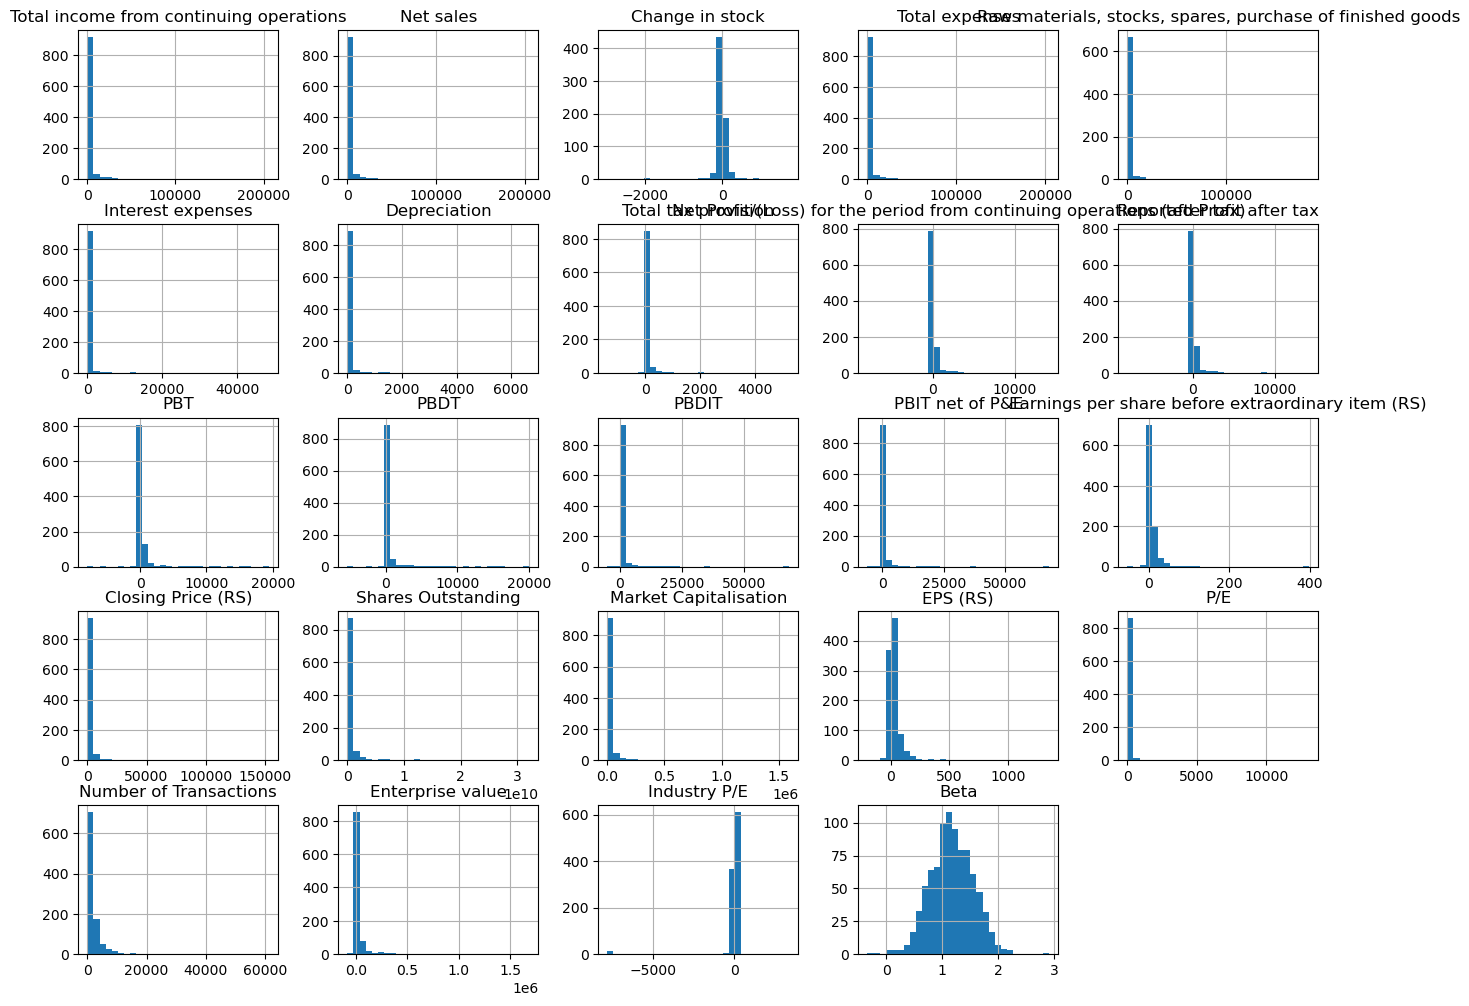

In [ ]:
# Histogram plot for numeric columns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].hist(figsize=(16,12), bins=30)
plt.show()


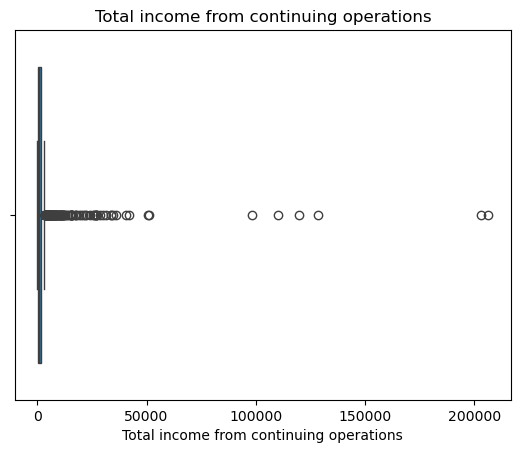

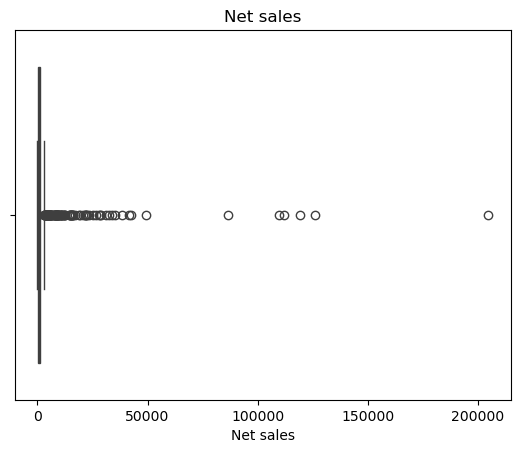

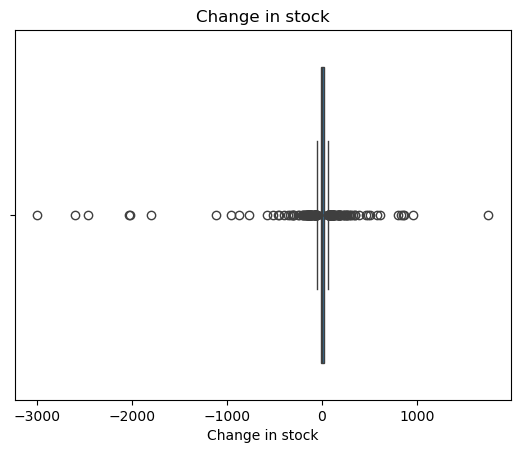

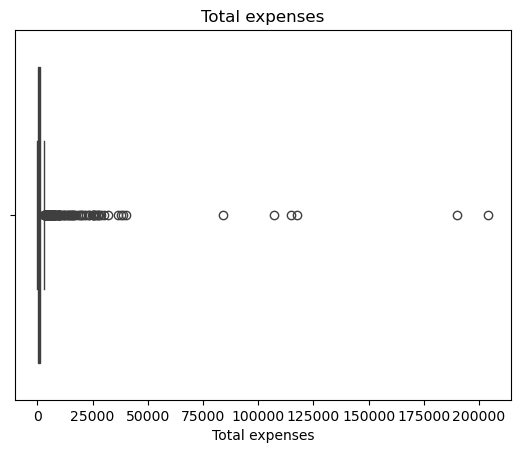

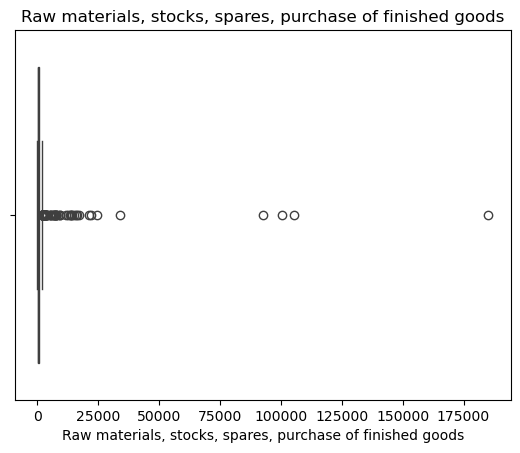

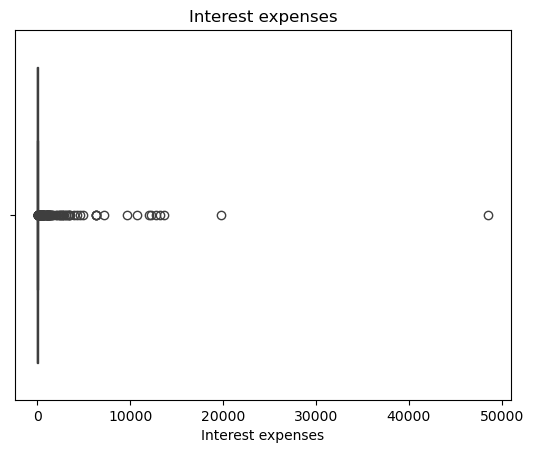

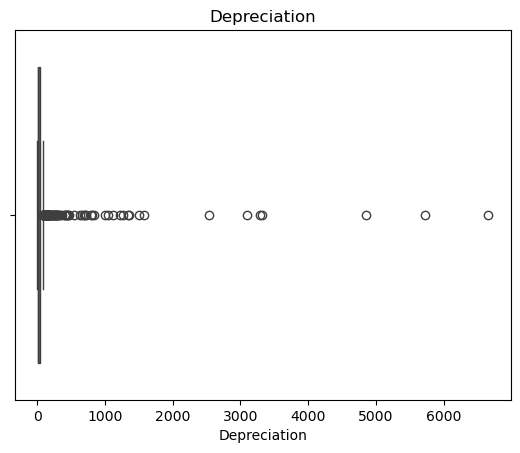

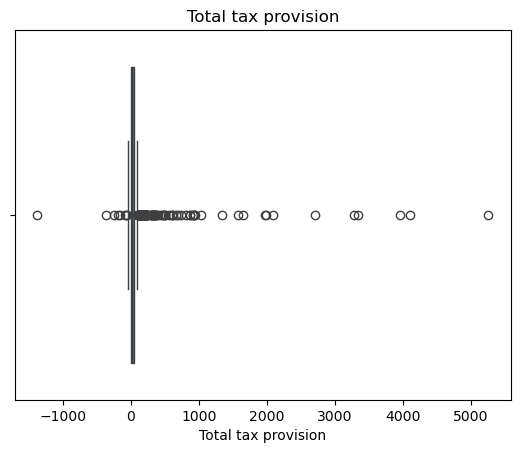

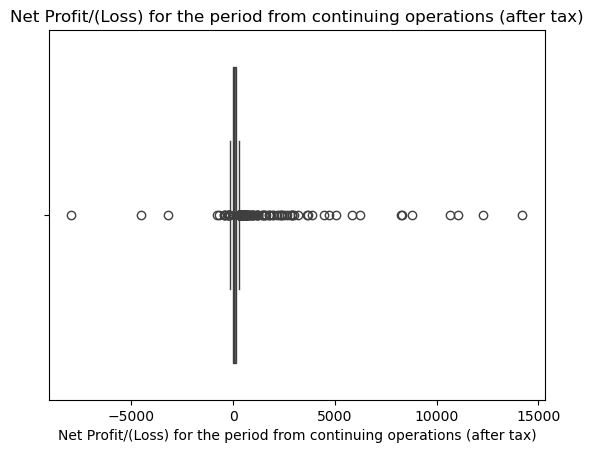

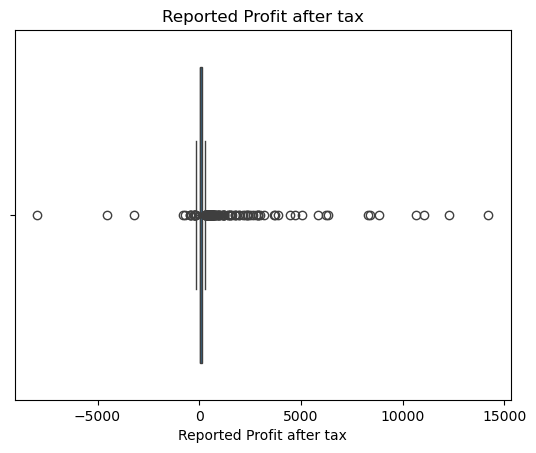

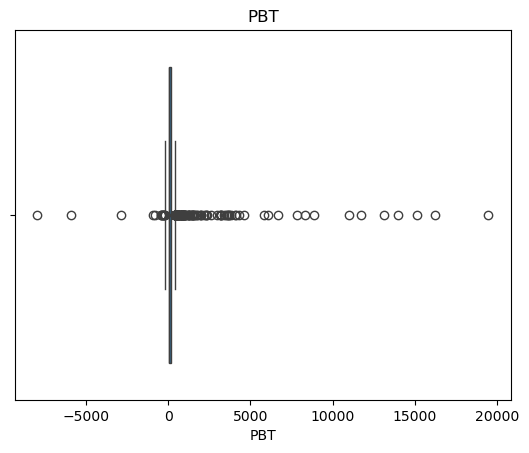

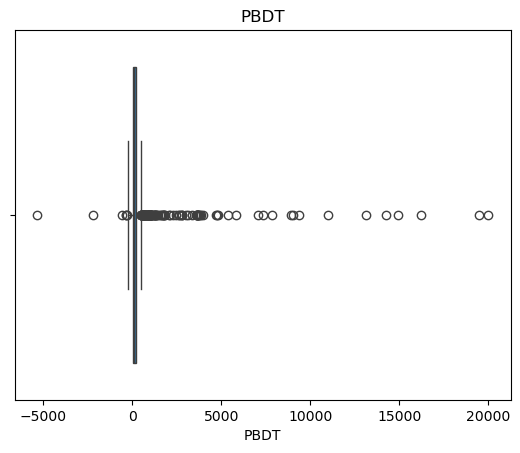

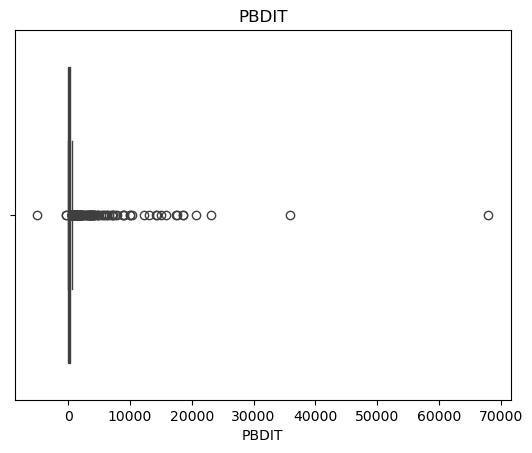

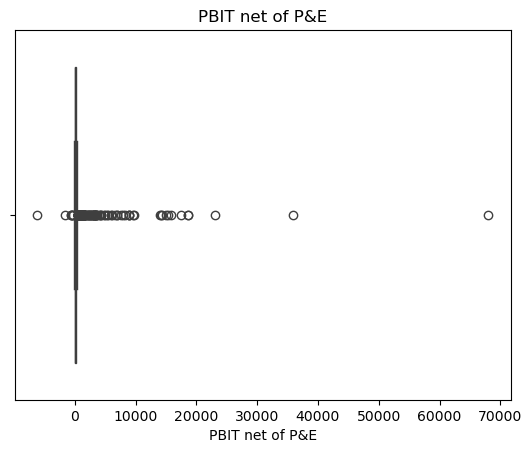

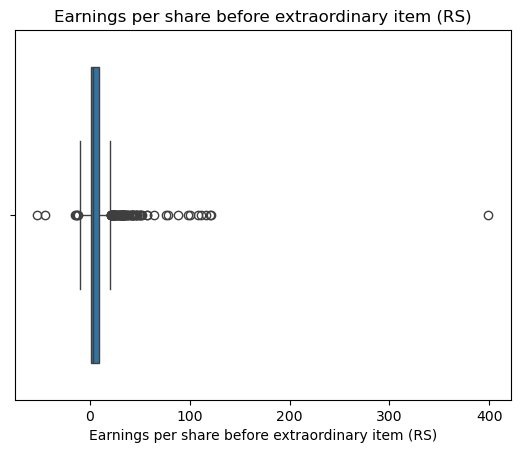

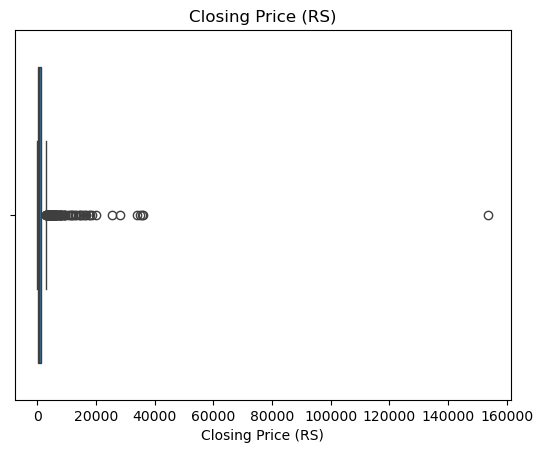

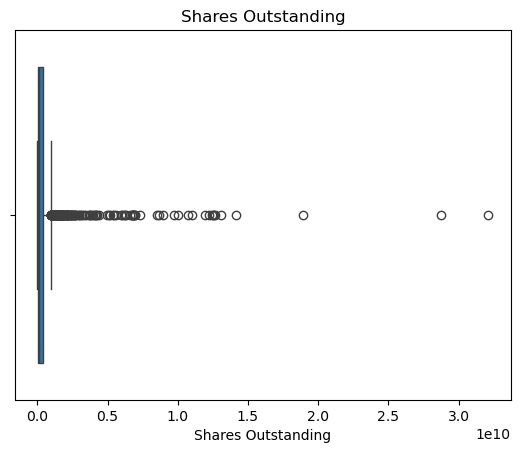

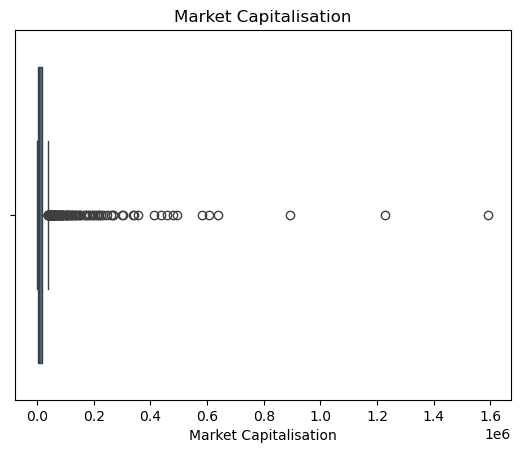

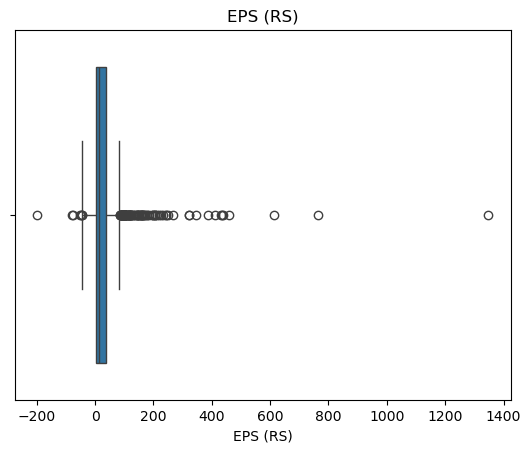

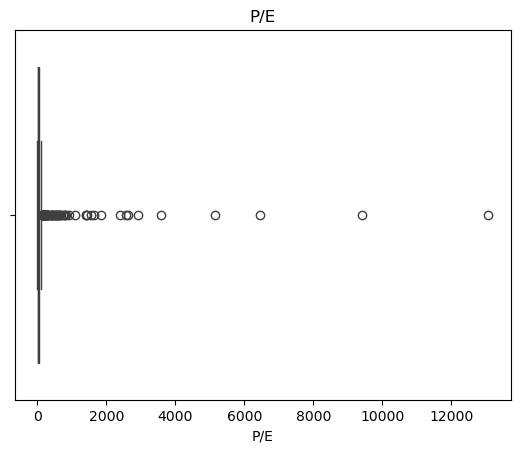

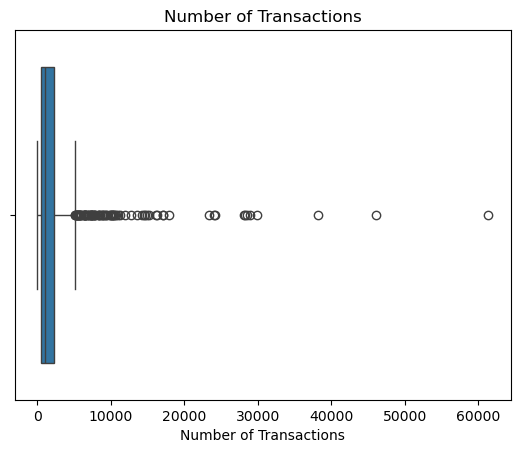

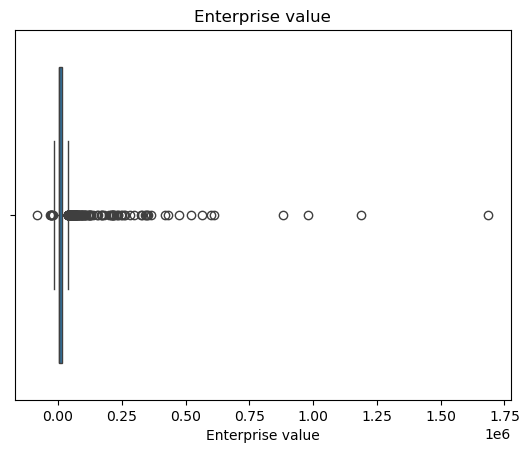

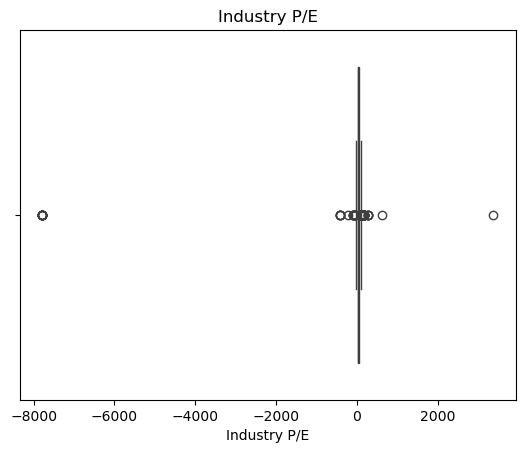

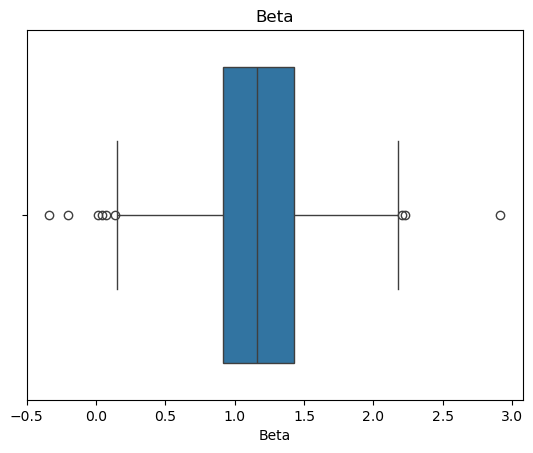

In [19]:
# boxplot

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


Strongest correlations (>|0.8|):
Reported Profit after tax                                                Net Profit/(Loss) for the period from continuing operations (after tax)    0.999988
Total expenses                                                           Total income from continuing operations                                    0.997007
PBT                                                                      Net Profit/(Loss) for the period from continuing operations (after tax)    0.995622
                                                                         Reported Profit after tax                                                  0.990314
PBIT net of P&E                                                          PBDIT                                                                      0.986320
Raw materials, stocks, spares, purchase of finished goods                Total expenses                                                             0.984877
PBDT                     

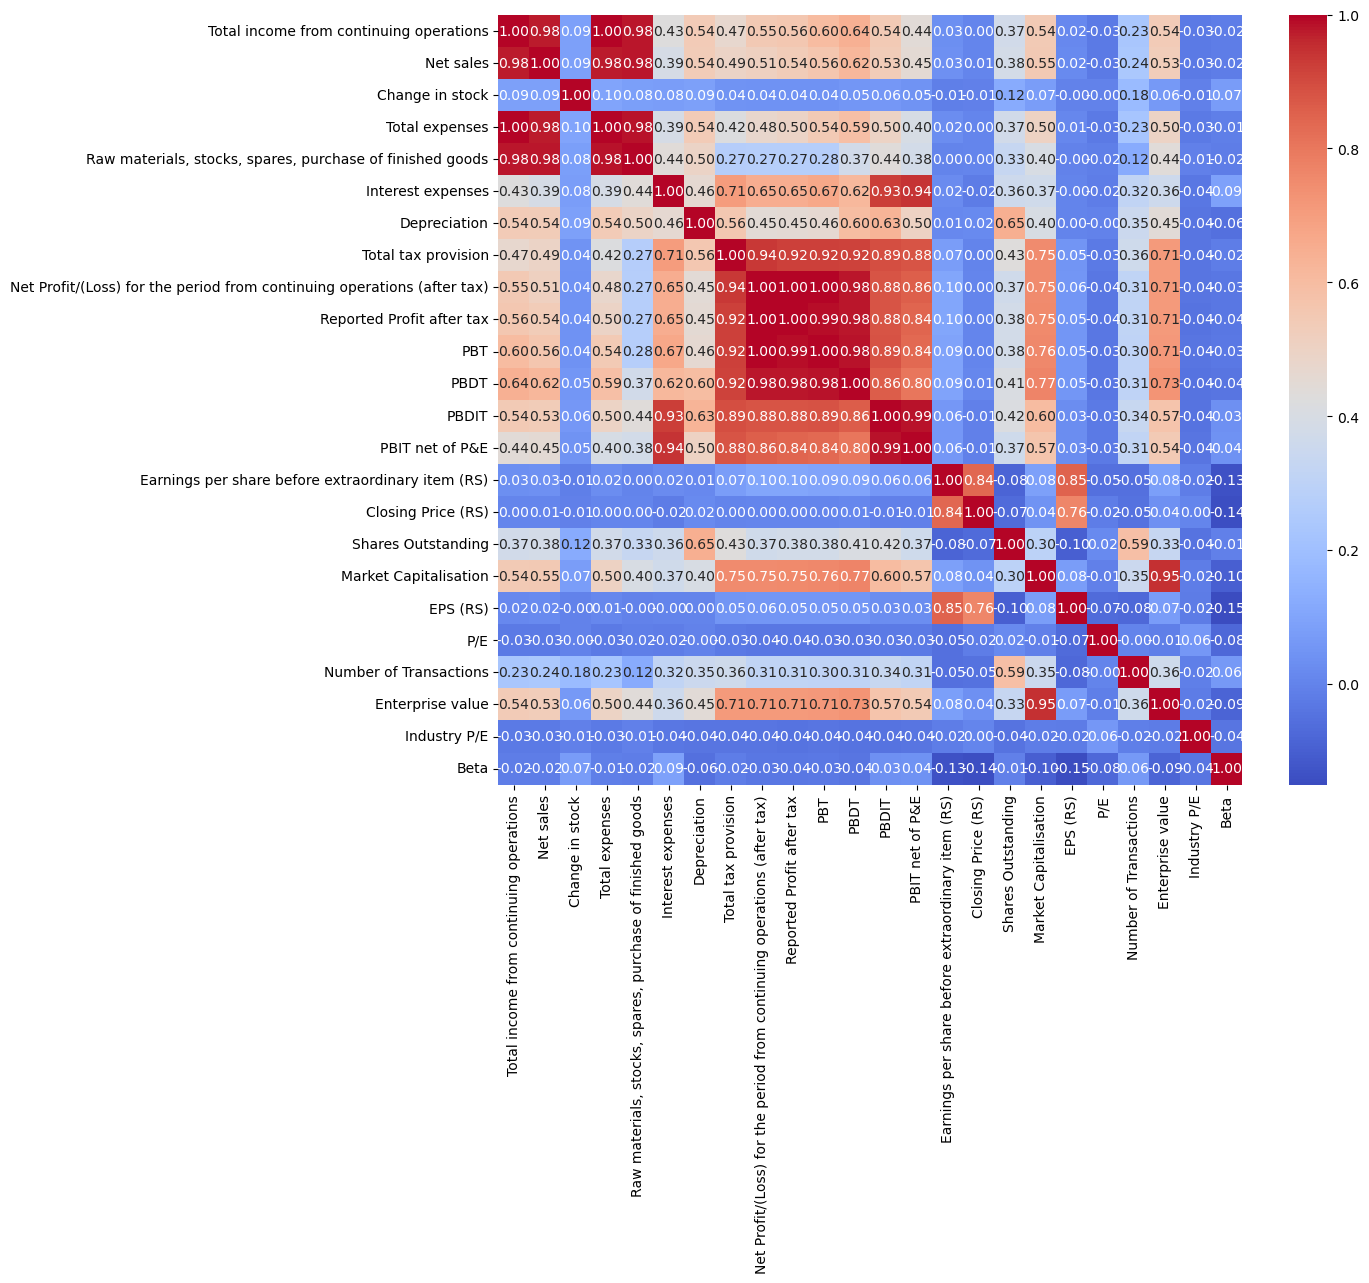

In [31]:
#correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show

#strongest correlations
corr_matrix = df[num_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corrs = upper_tri.unstack().dropna().sort_values(ascending=False)
strong_corrs = strong_corrs[strong_corrs > 0.8]
print("Strongest correlations (>|0.8|):")
print(strong_corrs)

# weakest correlations
weak_corrs = upper_tri.unstack().dropna().sort_values(ascending=True)
weak_corrs = weak_corrs[weak_corrs < 0.2]
print("Weakest correlations (<|0.2|):")
print(weak_corrs)

In [20]:
#Identify problematic columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

(df[num_cols] <= 0).sum()

Total income from continuing operations                                      0
Net sales                                                                    0
Change in stock                                                            301
Total expenses                                                               0
Raw materials, stocks, spares, purchase of finished goods                    0
Interest expenses                                                            0
Depreciation                                                                 0
Total tax provision                                                         54
Net Profit/(Loss) for the period from continuing operations (after tax)     84
Reported Profit after tax                                                   84
PBT                                                                         79
PBDT                                                                        58
PBDIT                                               

In [21]:
# fixing problematic columns for log scale transformation
df[num_cols] = df[num_cols].clip(lower=0)

In [22]:
#Using log1p

df_log = df.copy()
df_log[num_cols] = np.log1p(df[num_cols])

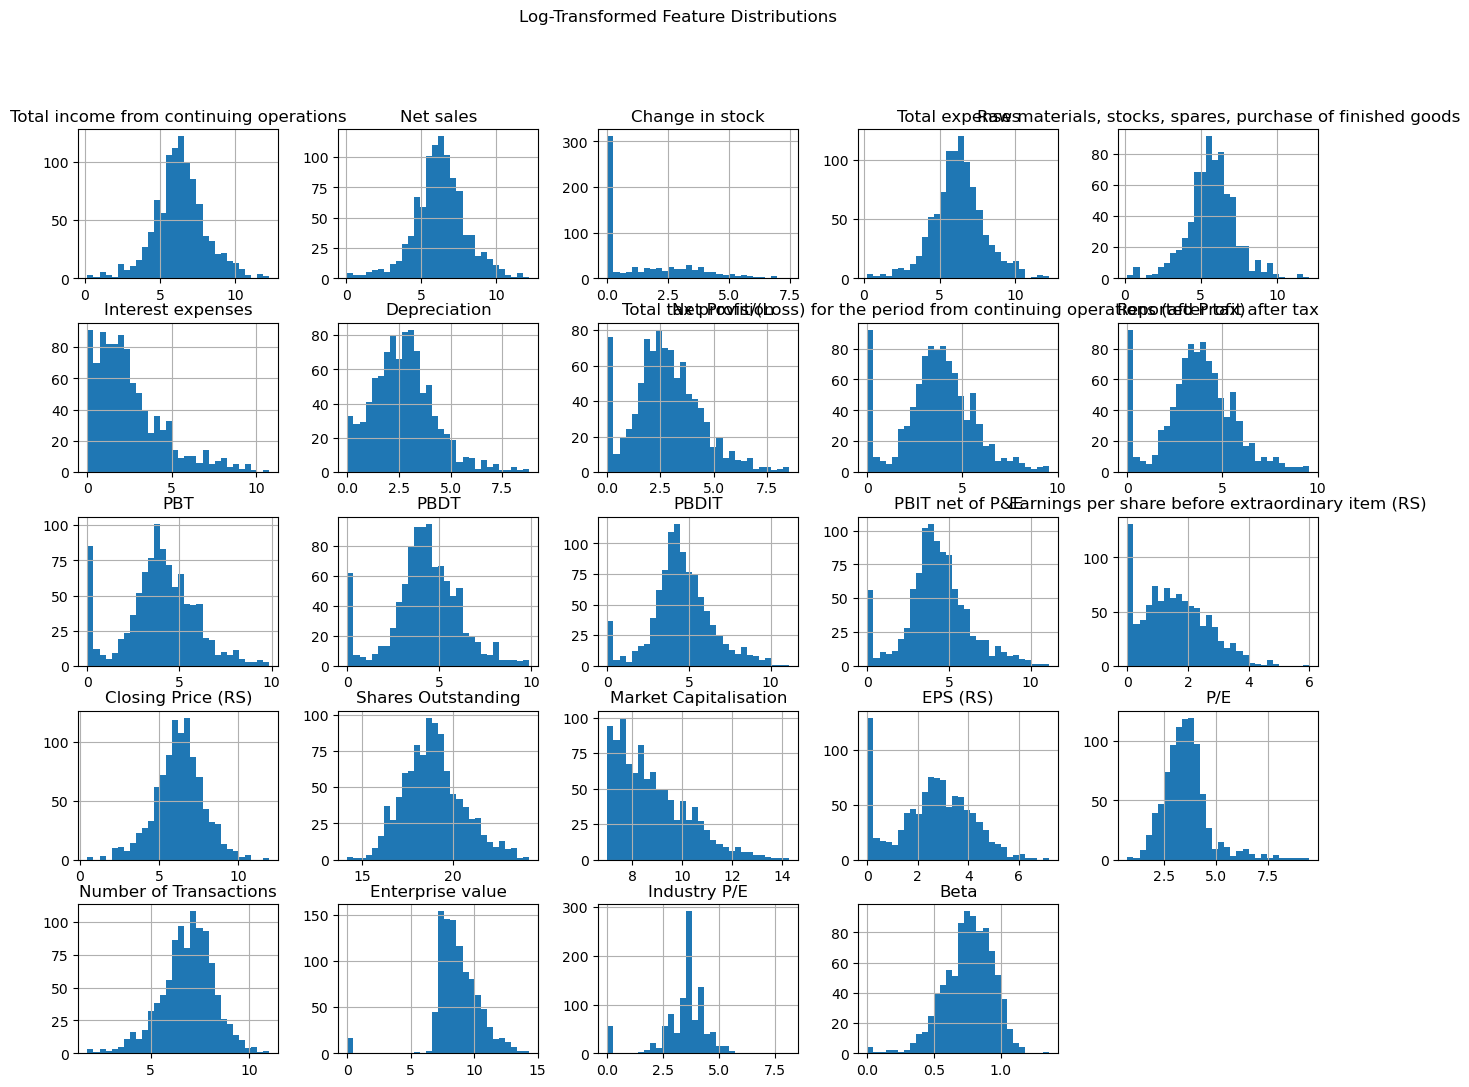

In [23]:
#Histogram (Log-transformed)
df_log[num_cols].hist(figsize=(16,12), bins=30)
plt.suptitle("Log-Transformed Feature Distributions")
plt.show()

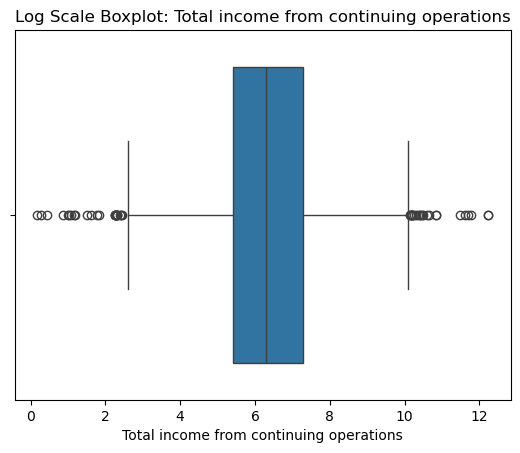

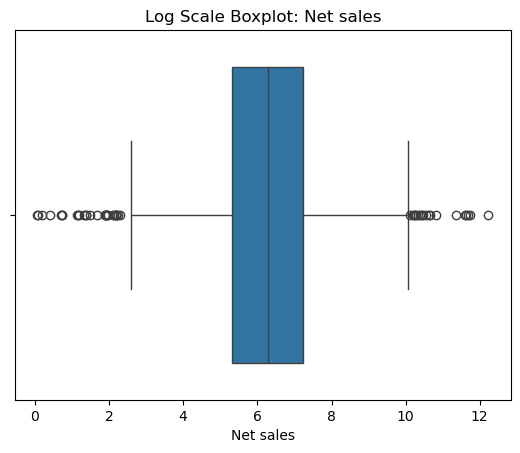

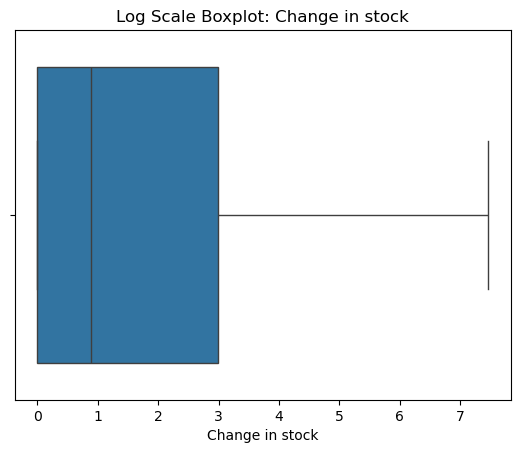

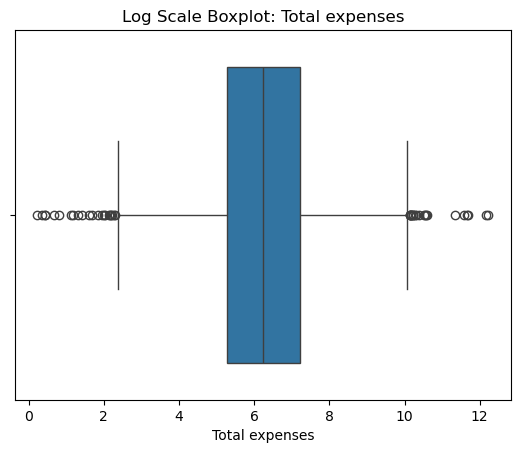

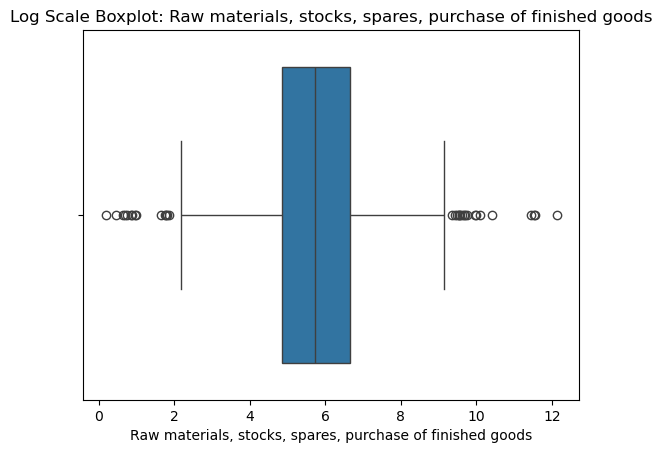

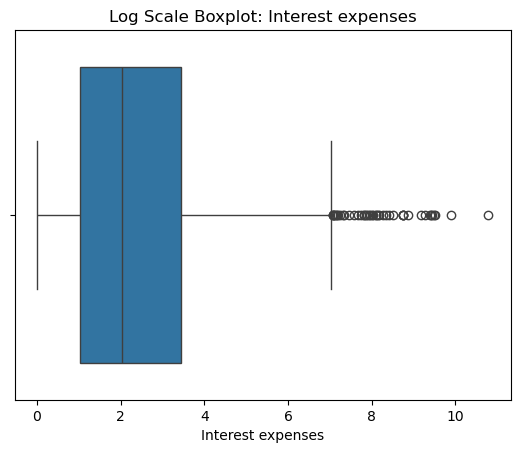

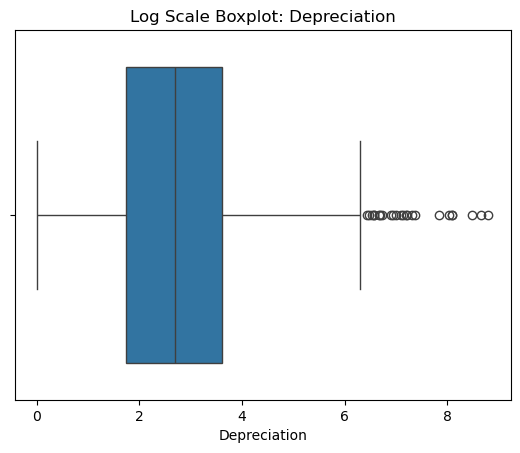

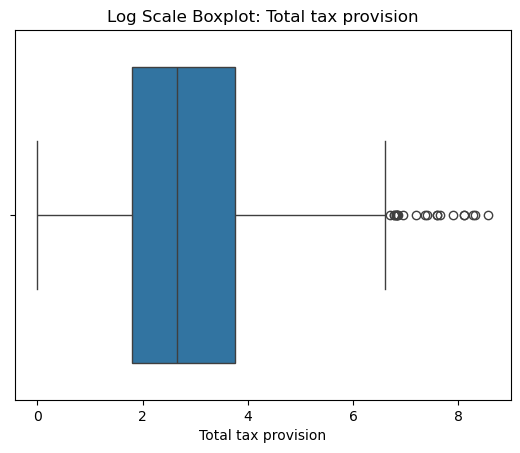

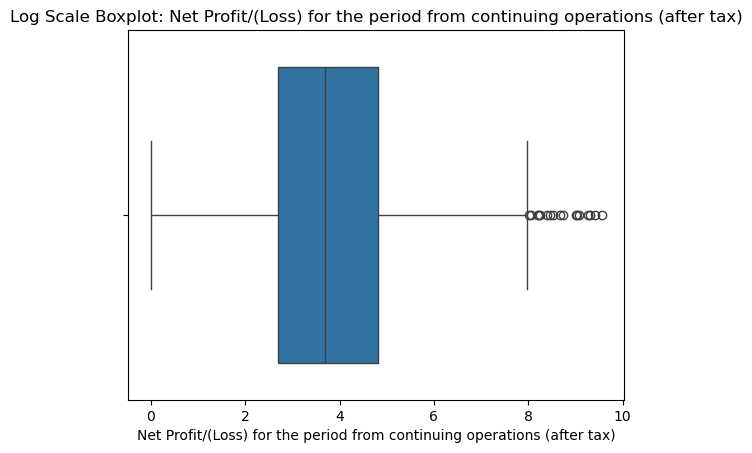

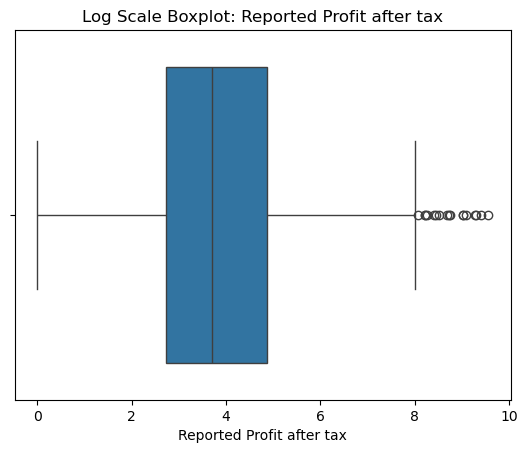

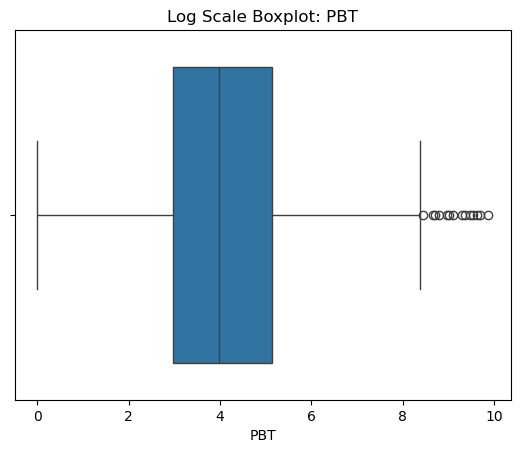

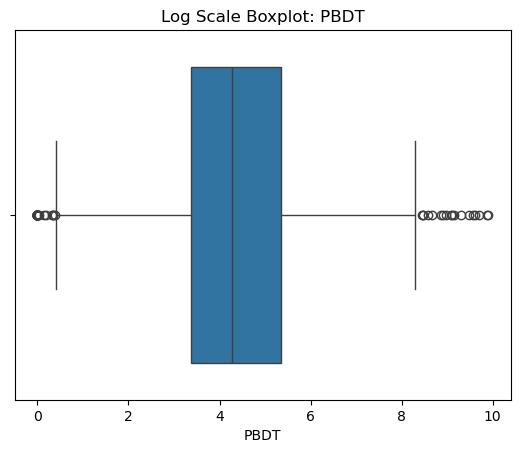

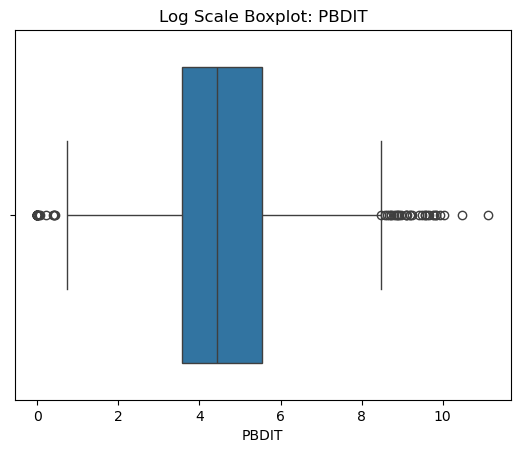

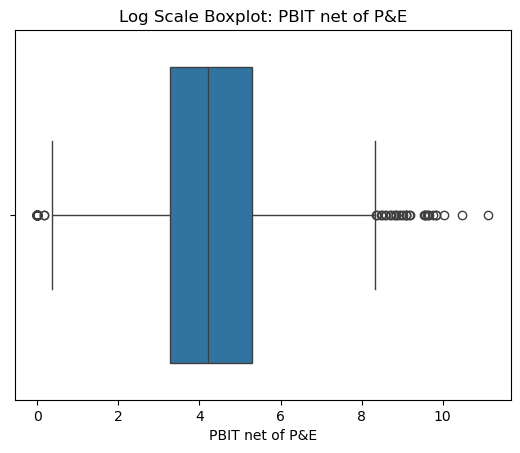

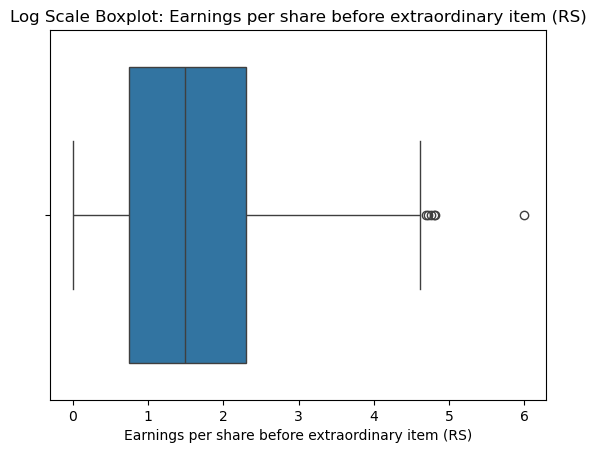

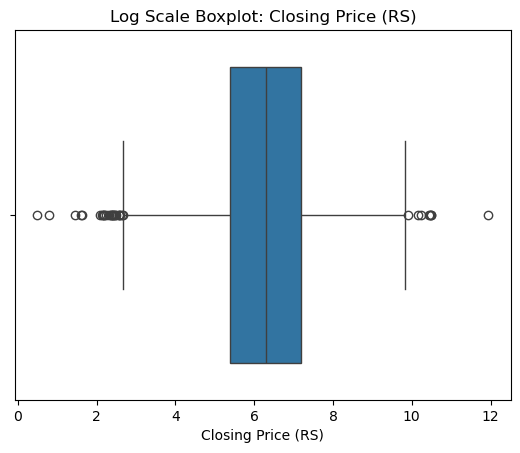

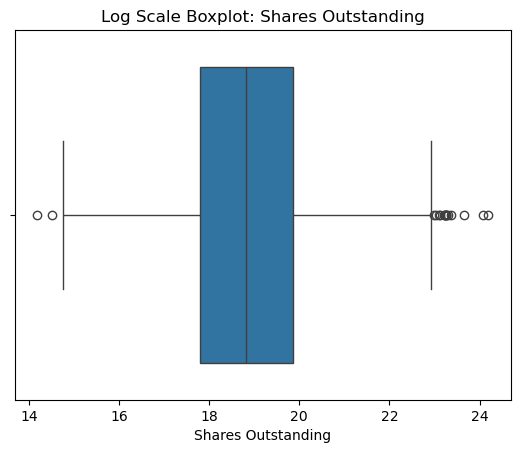

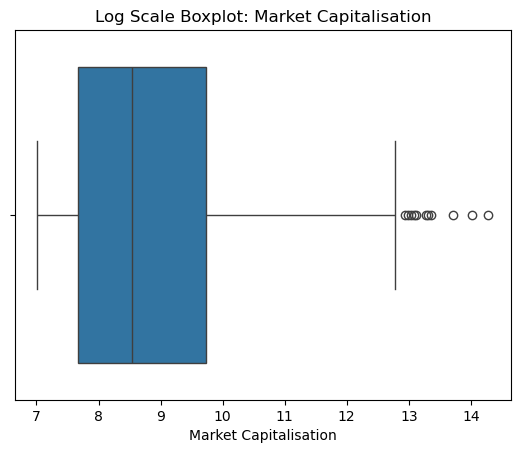

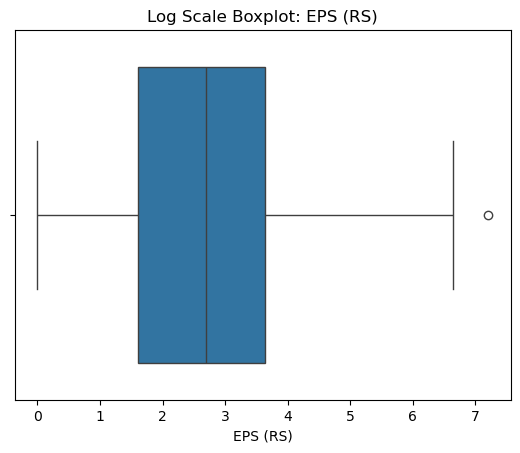

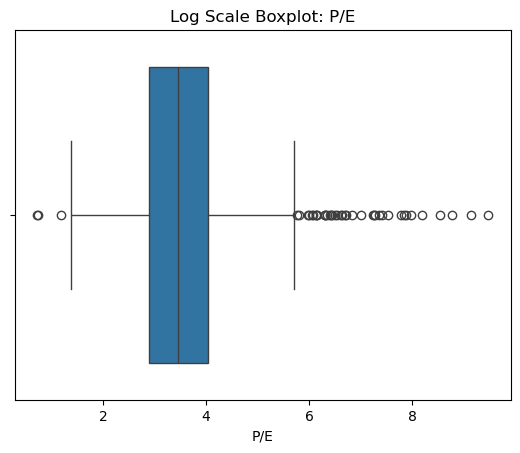

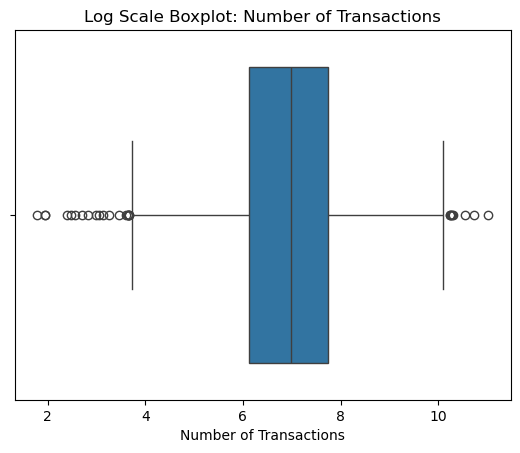

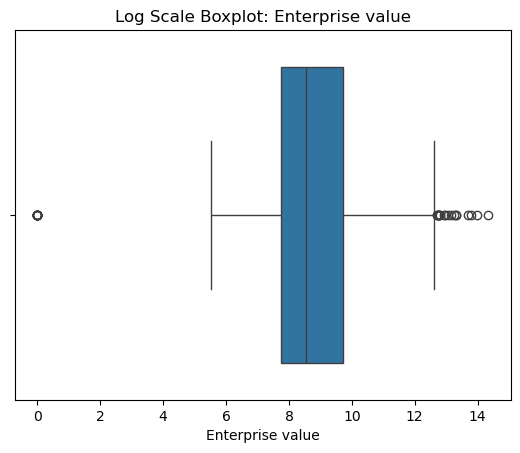

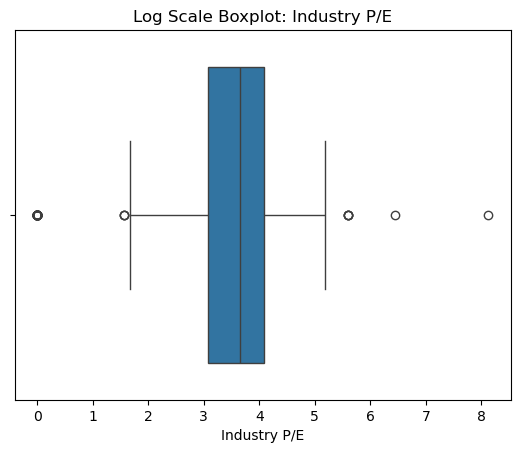

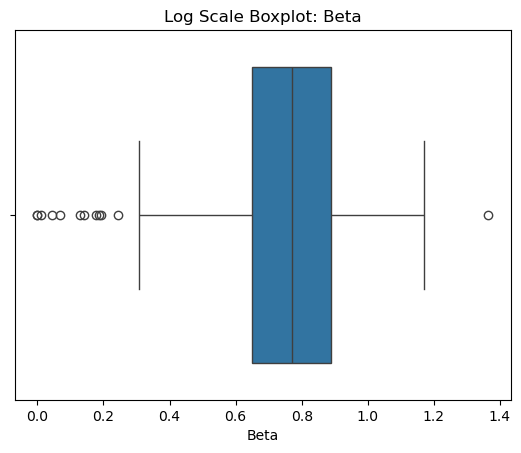

In [26]:
#log scale box plot
for col in num_cols:
    sns.boxplot(x=df_log[col])
    plt.title(f"Log Scale Boxplot: {col}")
    plt.show()

Strongest correlations in log scale (>|0.8|):
Reported Profit after tax                                                Net Profit/(Loss) for the period from continuing operations (after tax)    0.999883
PBT                                                                      Reported Profit after tax                                                  0.995133
                                                                         Net Profit/(Loss) for the period from continuing operations (after tax)    0.995006
Net sales                                                                Total income from continuing operations                                    0.990826
Total expenses                                                           Total income from continuing operations                                    0.986293
                                                                         Net sales                                                                  0.981211
PBDT        

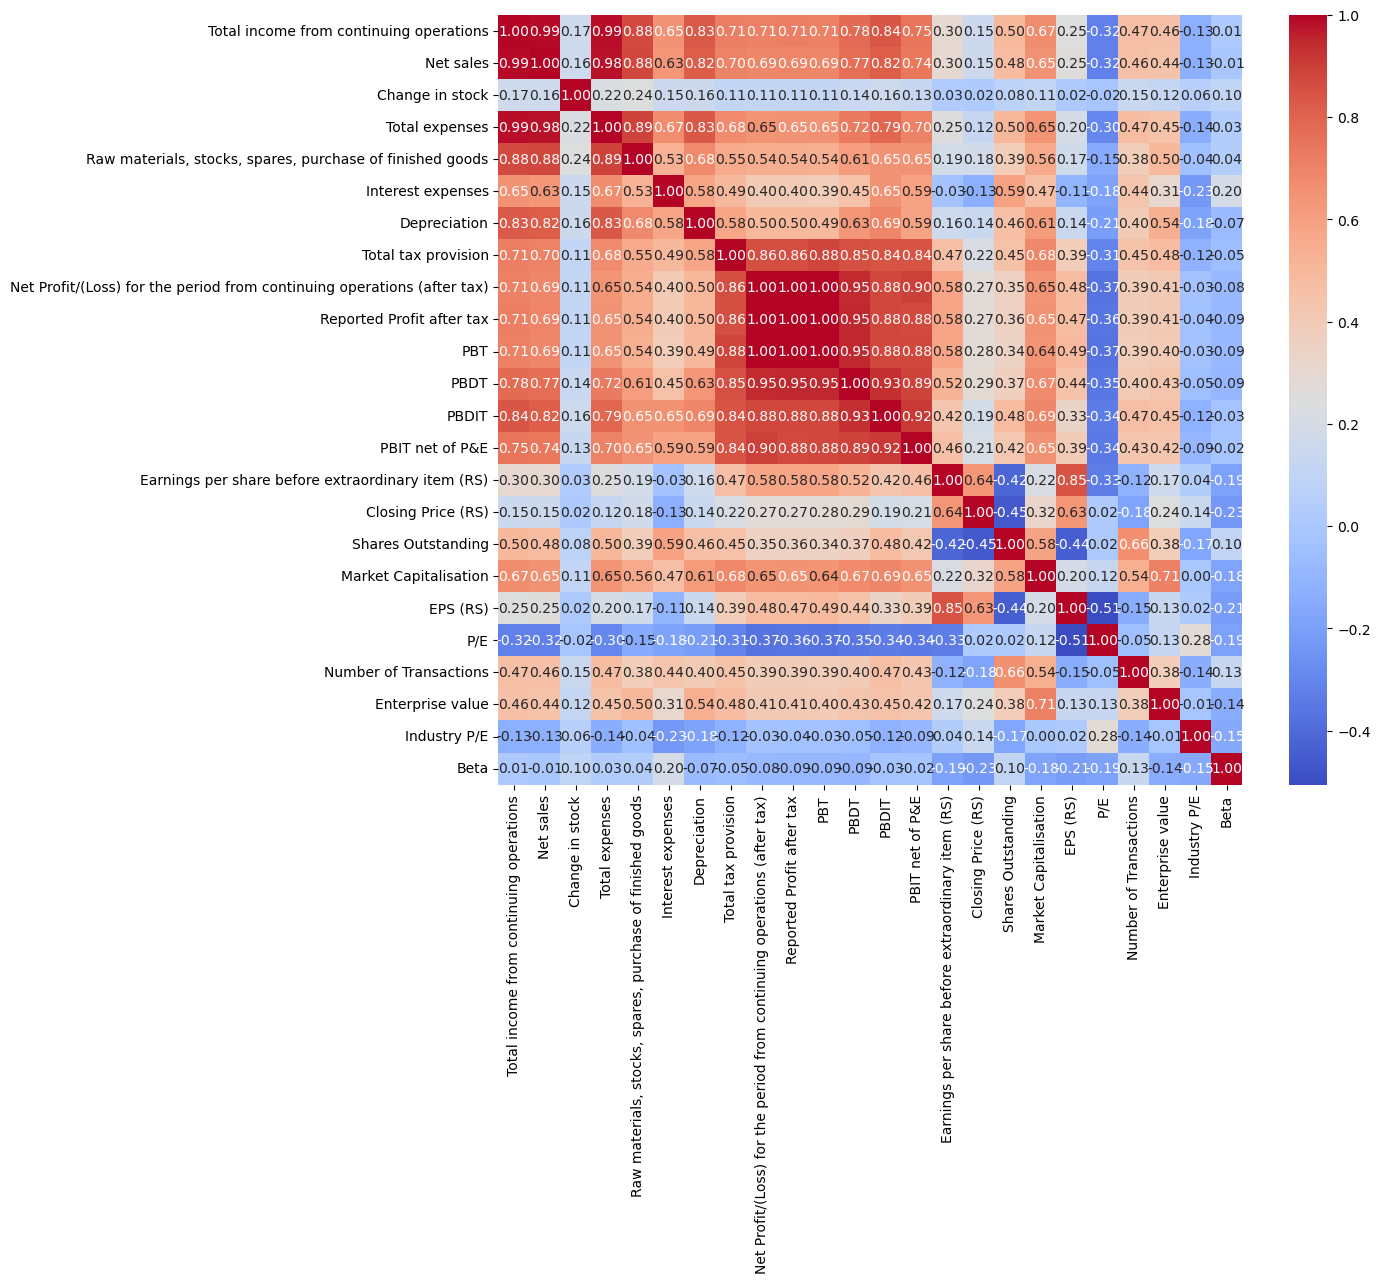

In [33]:
#correlation matrix in log scale
plt.figure(figsize=(12,10))
sns.heatmap(df_log[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show

#strongest and weakest correlations in log scale
corr_matrix_log = df_log[num_cols].corr().abs()
upper_tri_log = corr_matrix_log.where(np.triu(np.ones(corr_matrix_log.shape), k=1).astype(bool))
strong_corrs_log = upper_tri_log.unstack().dropna().sort_values(ascending=False)
strong_corrs_log = strong_corrs_log[strong_corrs_log > 0.8]
weak_corrs_log = upper_tri_log.unstack().dropna().sort_values(ascending=True)
weak_corrs_log = weak_corrs_log[weak_corrs_log < 0.2]
print("Strongest correlations in log scale (>|0.8|):")
print(strong_corrs_log)
print("weakest correlations in log scale (<|0.2|)")
print(weak_corrs_log)

In [27]:
#Missing % per column
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False)

Change in stock                                                            30.730731
Raw materials, stocks, spares, purchase of finished goods                  30.130130
Beta                                                                       11.711712
P/E                                                                        10.410410
Total tax provision                                                         7.207207
Depreciation                                                                6.106106
Interest expenses                                                           4.704705
Net Profit/(Loss) for the period from continuing operations (after tax)     1.301301
Earnings per share before extraordinary item (RS)                           1.001001
Net sales                                                                   0.800801
Enterprise value                                                            0.800801
PBIT net of P&E                                                  

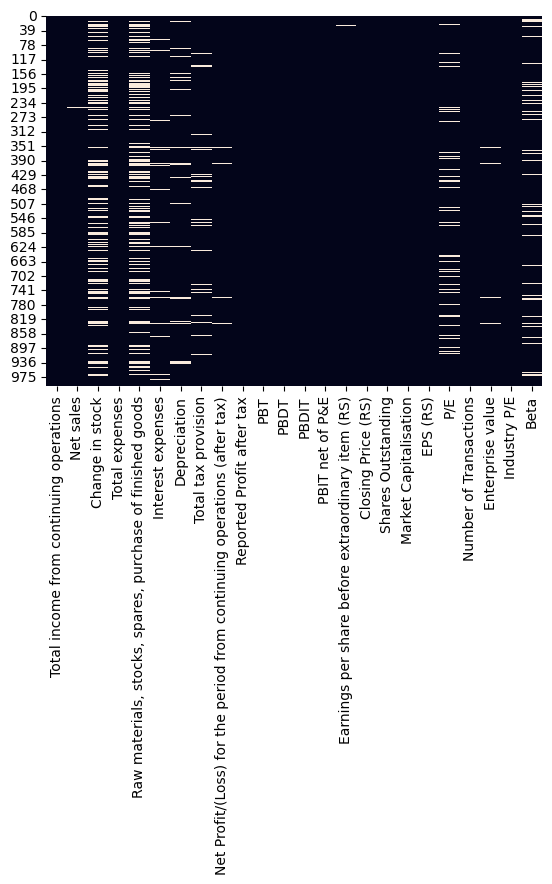

In [28]:
sns.heatmap(df[num_cols].isna(), cbar=False)
plt.show()

In [35]:
#imputation 
# Select numeric columns
zero_fill_cols = [         
    'Company Name', 'Industry group', 'Closing Price (RS)', 'Shares Outstanding',
    'EPS (RS)', 'Market Capitalisation', 'Number of Transactions', 'Industry P/E'
]
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove columns we do NOT want to impute
numeric_cols = [
    col for col in numeric_cols
    if col not in zero_fill_cols 
]
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove columns we do NOT want to impute
numeric_cols = [
    col for col in numeric_cols
    if col not in zero_fill_cols 
]

# Industry-wise median imputation
for col in numeric_cols:
    df[col] = (
        df.groupby("Industry group")[col]
          .transform(lambda x: x.fillna(x.median()))
    )
    
    # fallback: global median if industry median missing
    df[col] = df[col].fillna(df[col].median())


In [37]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False)

Company Name                                                               0.0
Industry group                                                             0.0
Total income from continuing operations                                    0.0
Net sales                                                                  0.0
Change in stock                                                            0.0
Total expenses                                                             0.0
Raw materials, stocks, spares, purchase of finished goods                  0.0
Interest expenses                                                          0.0
Depreciation                                                               0.0
Total tax provision                                                        0.0
Net Profit/(Loss) for the period from continuing operations (after tax)    0.0
Reported Profit after tax                                                  0.0
PBT                                                 

Visualization after imputation

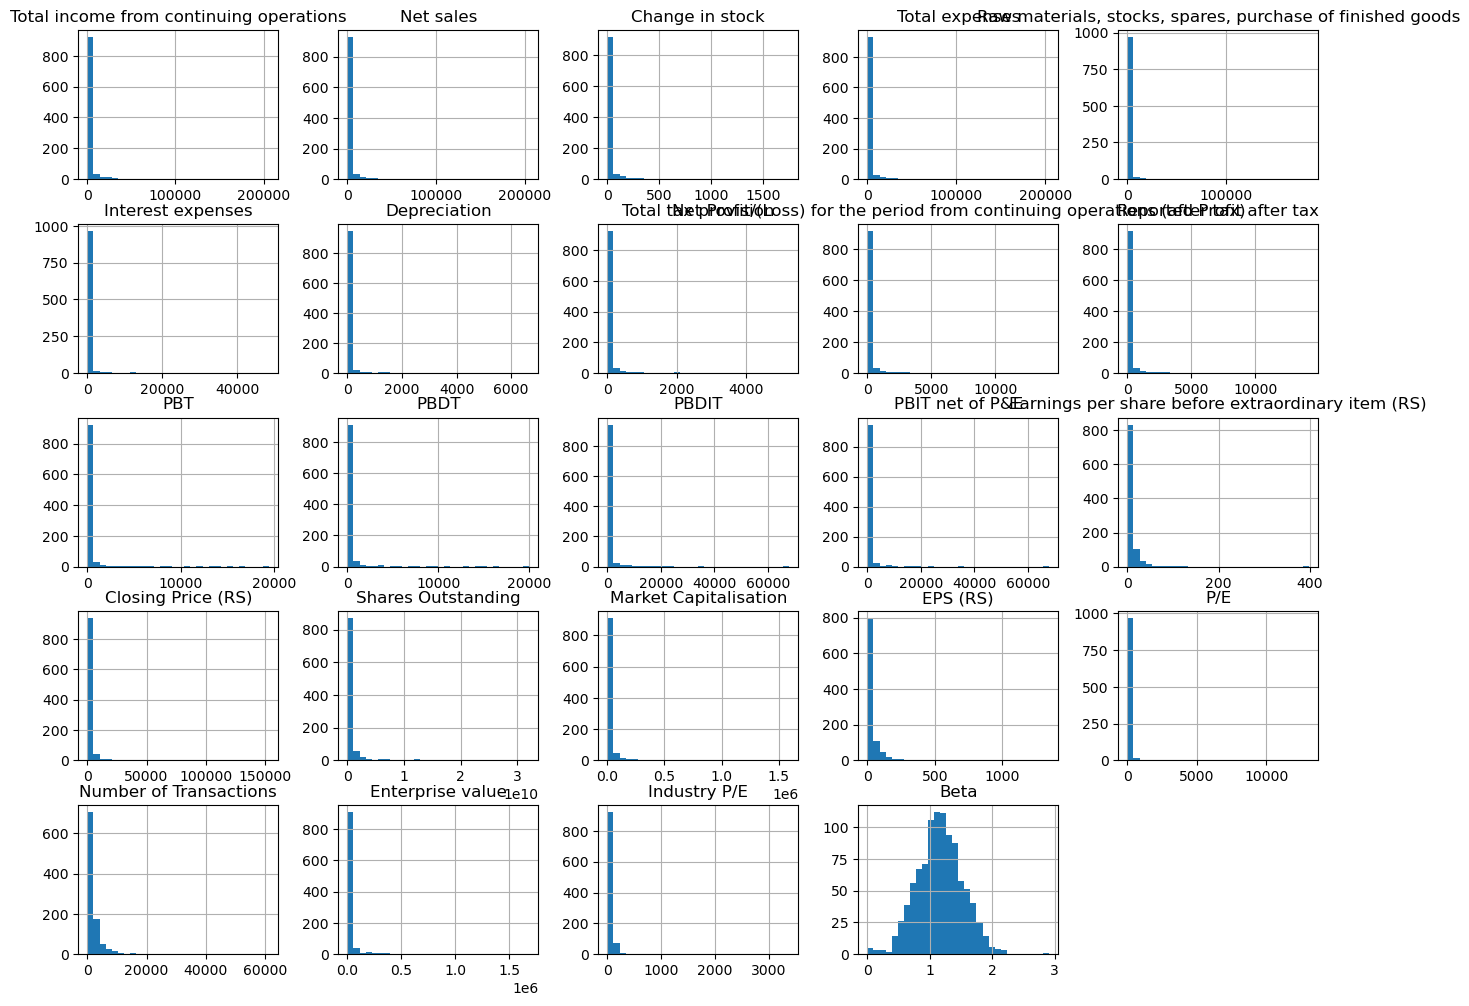

In [38]:
# visualization
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].hist(figsize=(16,12), bins=30)
plt.show()


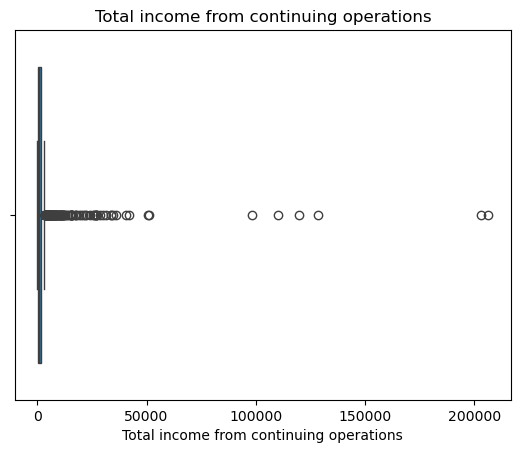

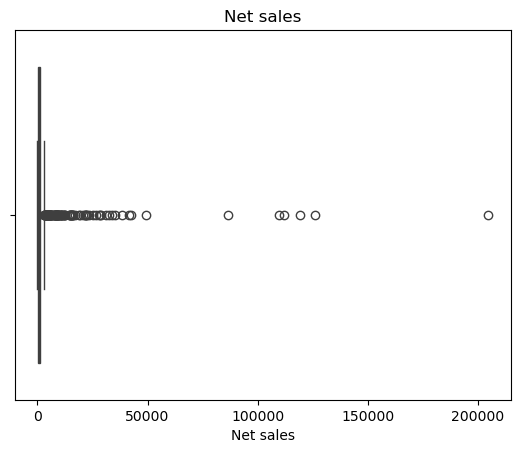

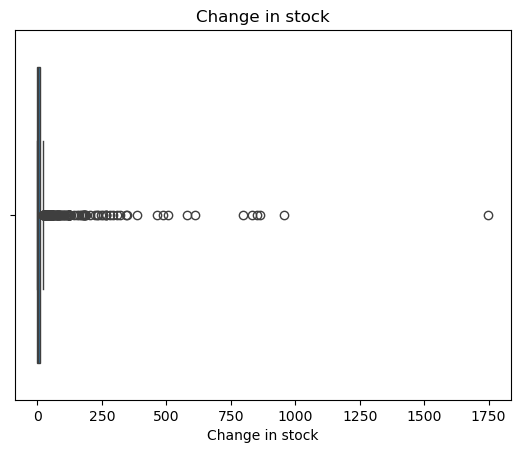

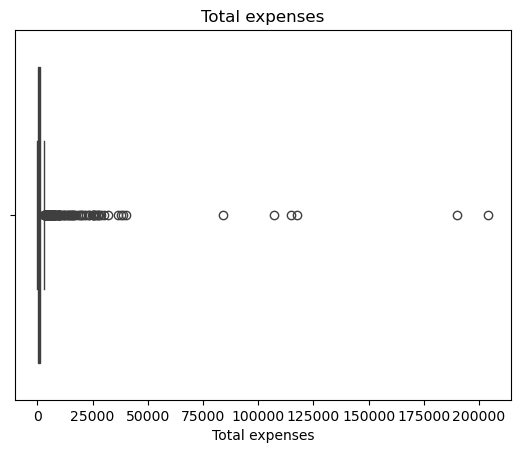

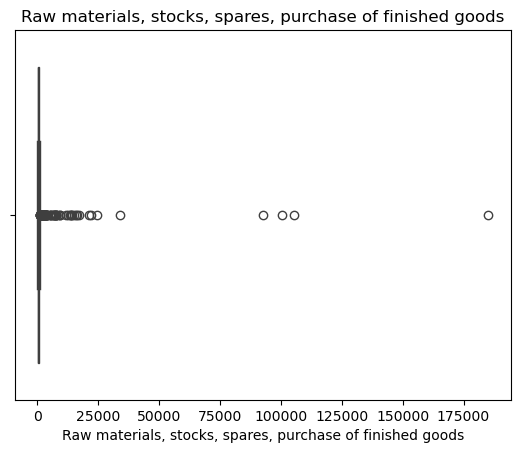

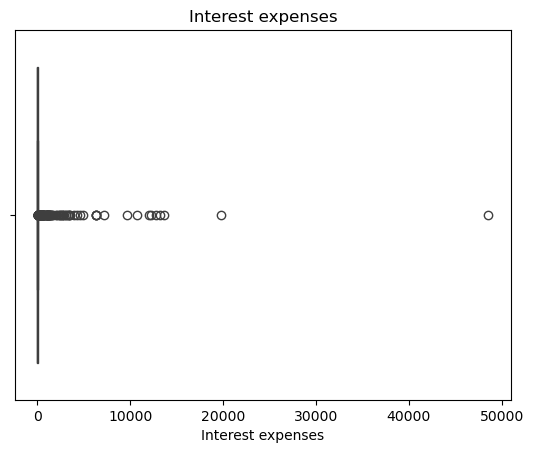

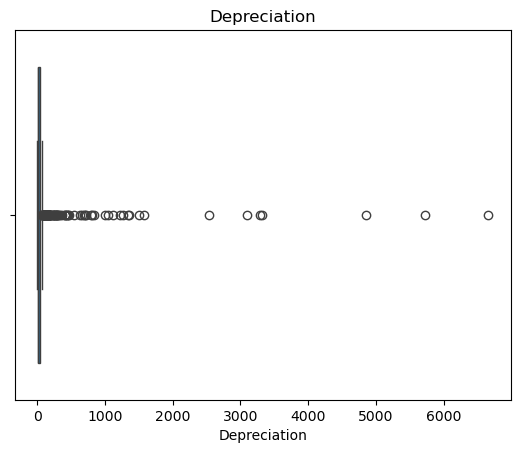

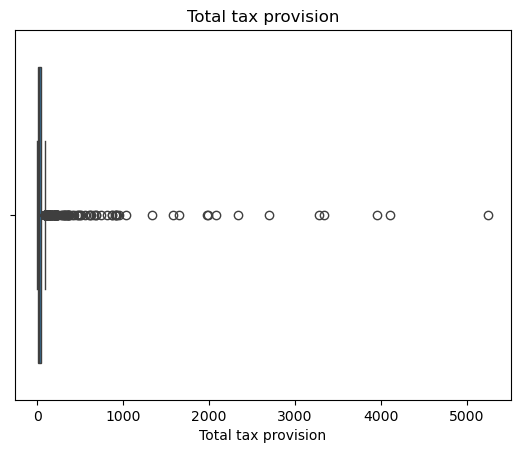

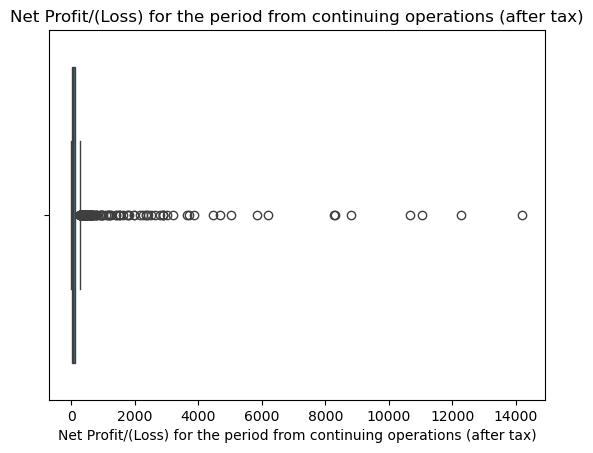

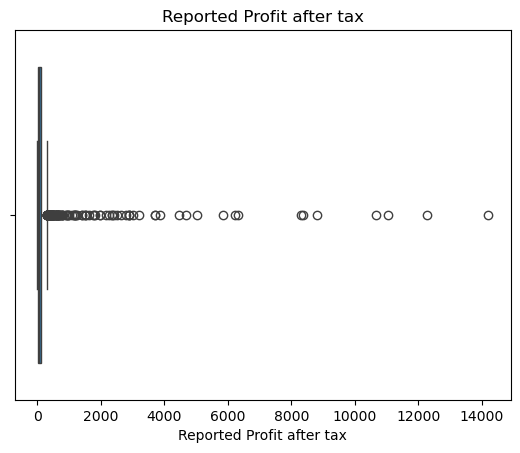

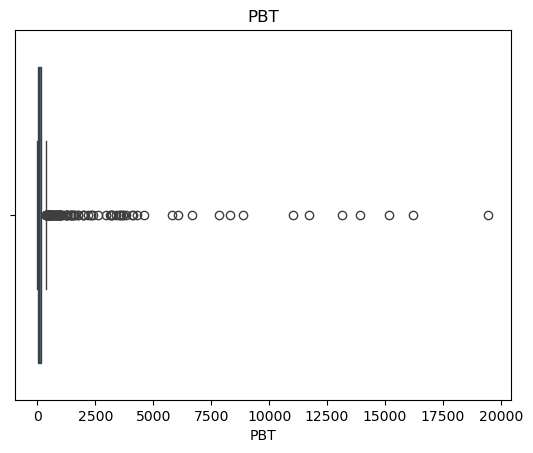

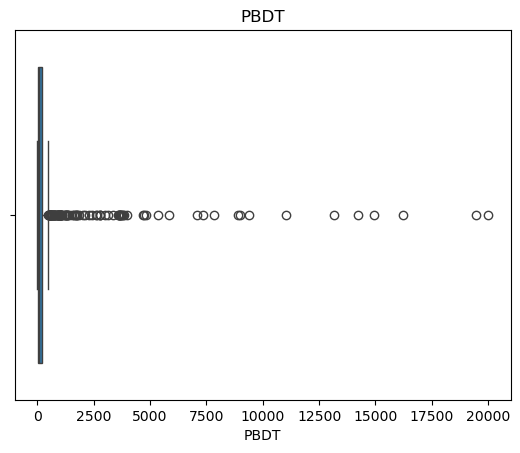

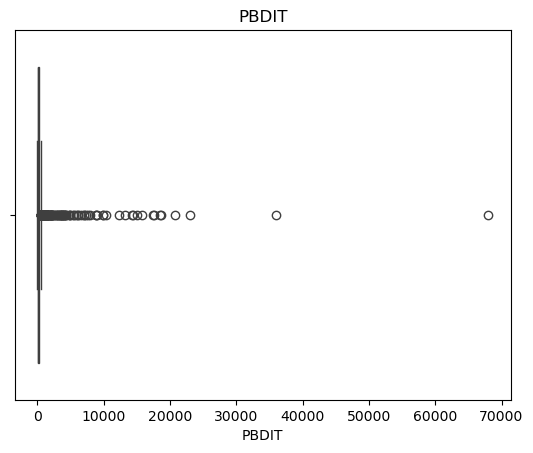

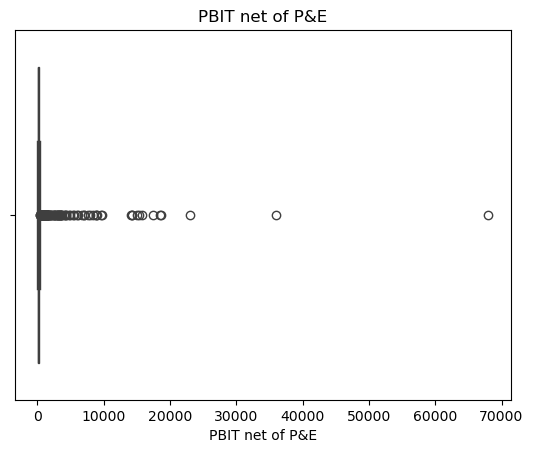

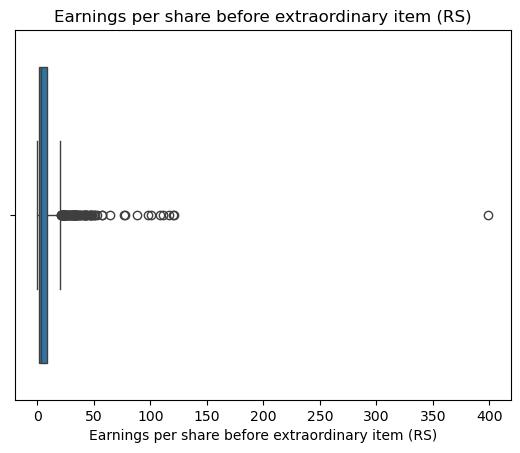

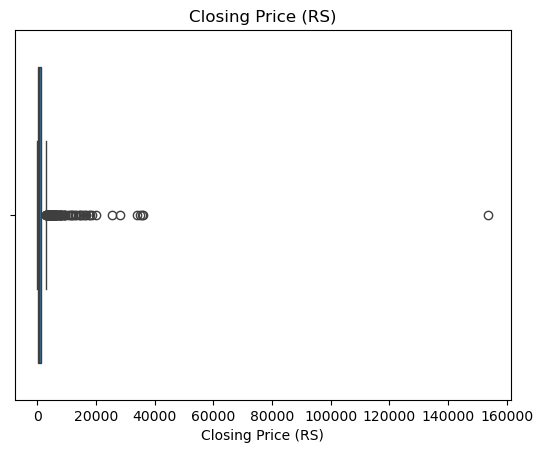

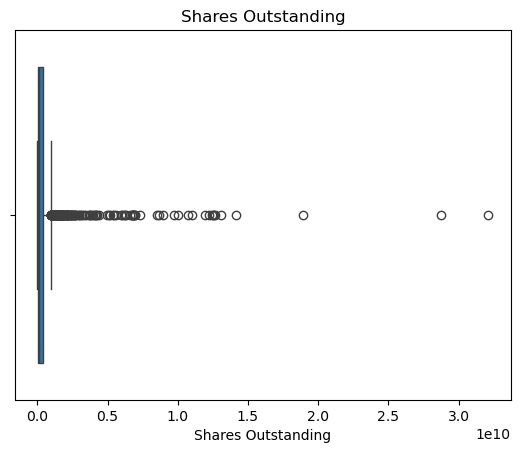

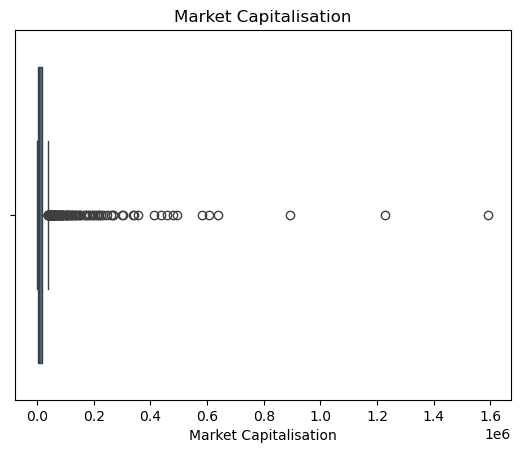

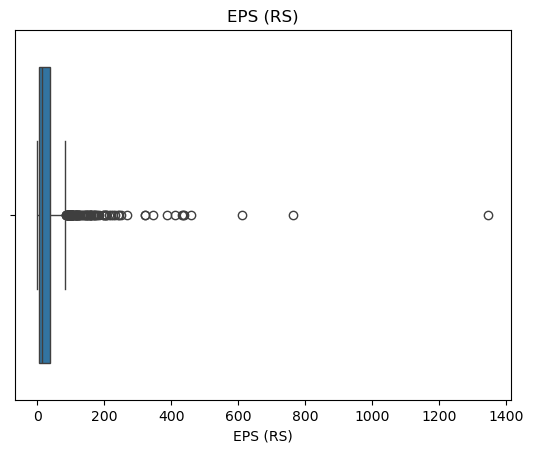

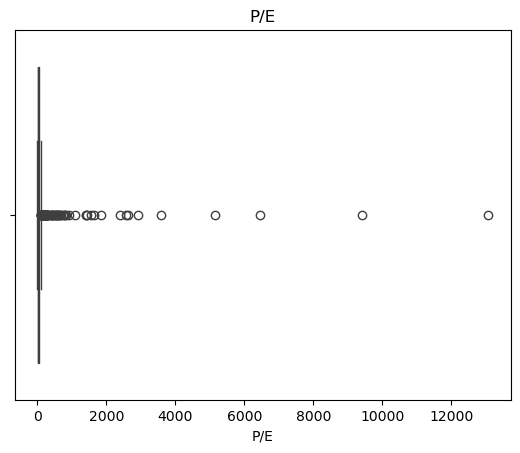

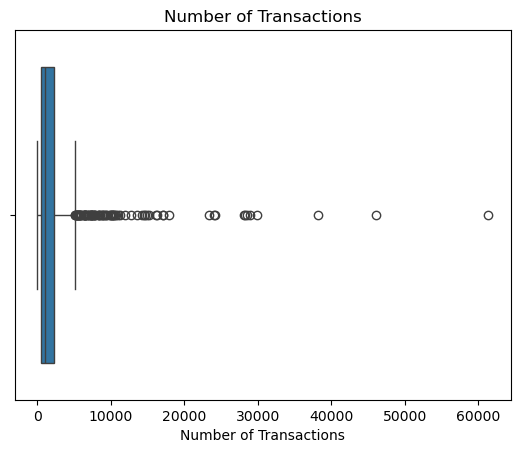

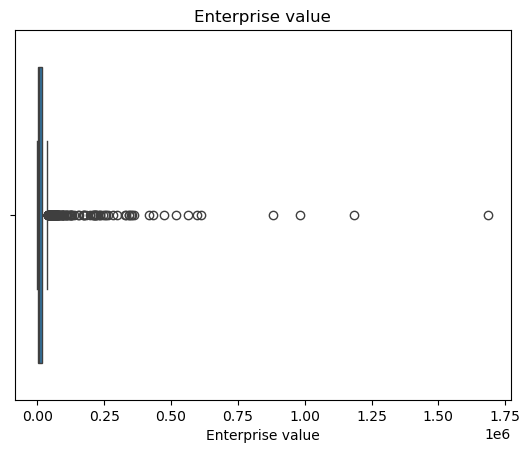

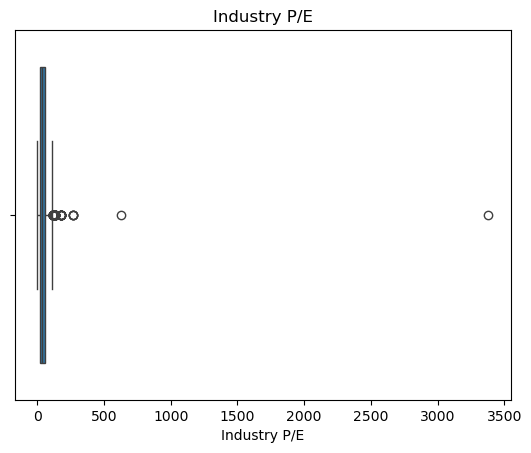

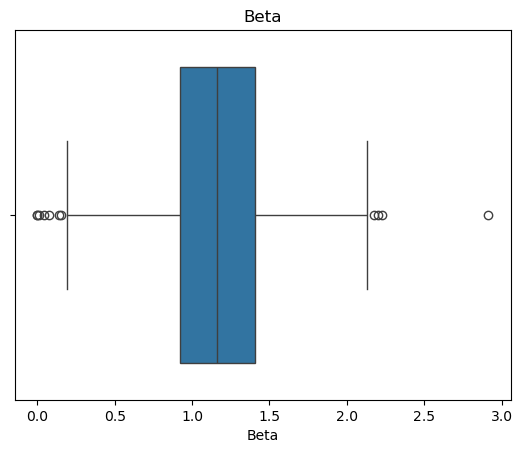

In [39]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [42]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outliers,
        "outlier_pct": (outliers / len(df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df.sort_values("outlier_pct", ascending=False)


,lower_bound,upper_bound,outlier_count,outlier_pct
Change in stock,-1.324500e+01,2.207500e+01,176.0,17.617618
Interest expenses,-3.569000e+01,6.451000e+01,175.0,17.517518
Shares Outstanding,-4.917574e+08,9.635465e+08,146.0,14.614615
PBDIT,-2.901675e+02,5.750525e+02,139.0,13.913914
PBIT net of P&E,-2.313675e+02,4.532925e+02,138.0,13.813814
Net Profit/(Loss) for the period from continuing operations (after tax),-1.425550e+02,2.755650e+02,136.0,13.613614
Net sales,-1.532500e+03,3.099900e+03,134.0,13.413413
Total income from continuing operations,-1.592035e+03,3.239805e+03,134.0,13.413413
Total tax provision,-4.515750e+01,8.938250e+01,134.0,13.413413
Market Capitalisation,-1.986896e+04,3.879389e+04,133.0,13.313313


In [43]:
# IQR-based Clipping (Winsorization)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)



In [ ]:
# Log transformation after imputation
df_log_imputed = df.copy()
df_log_imputed[num_cols] = np.log1p(df[num_cols])

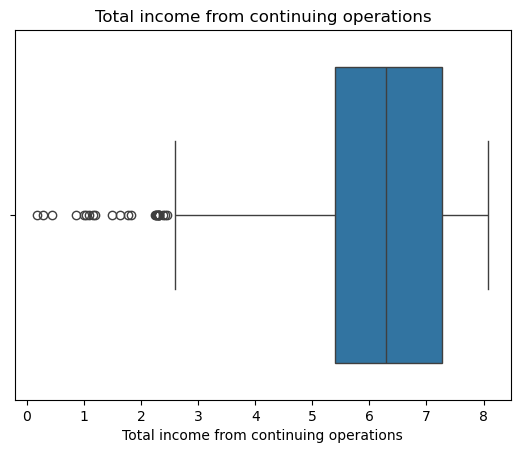

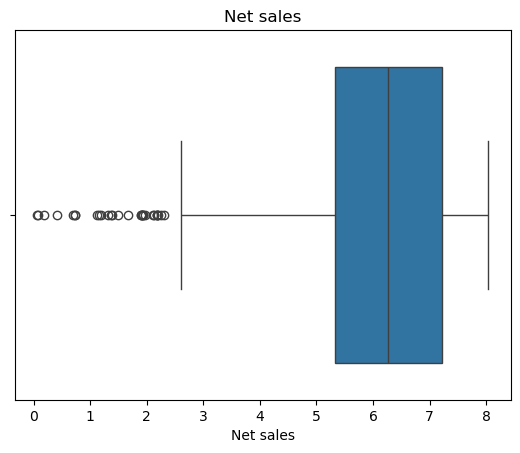

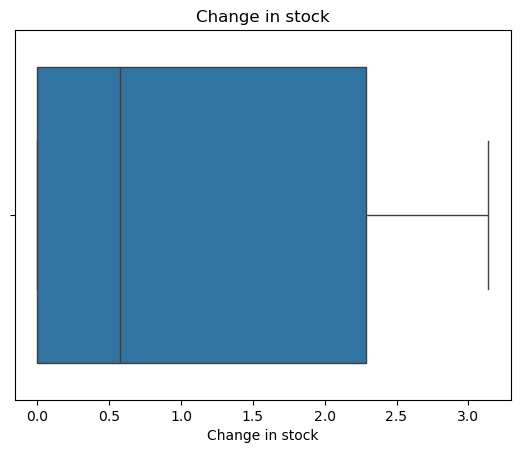

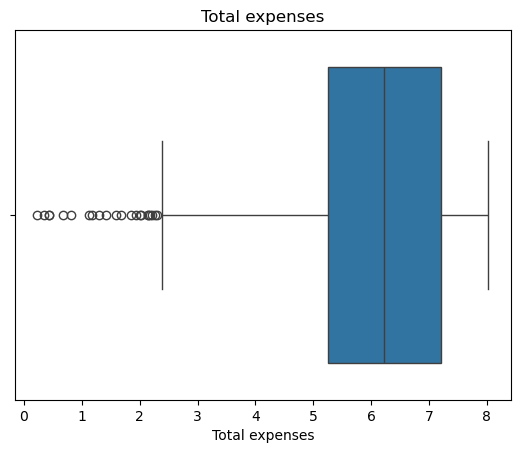

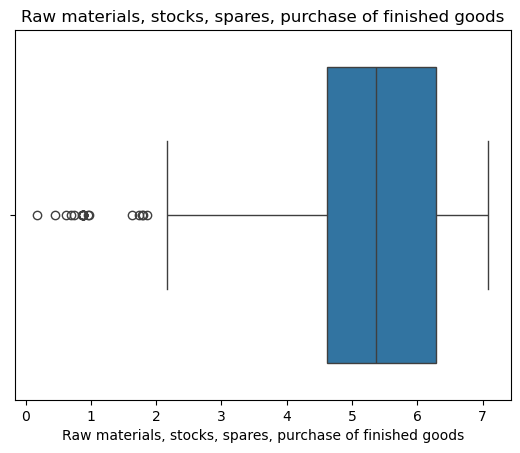

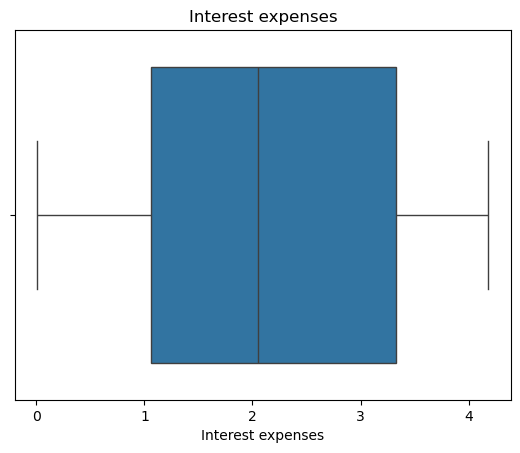

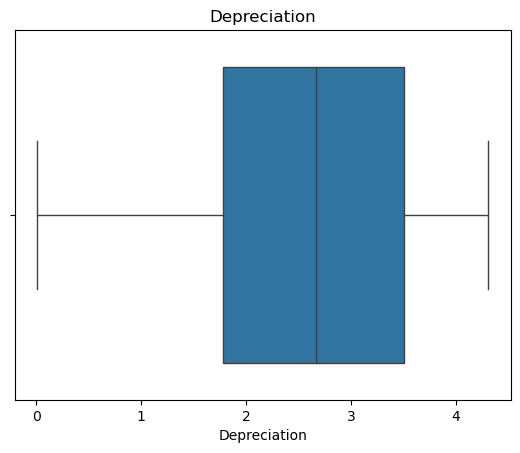

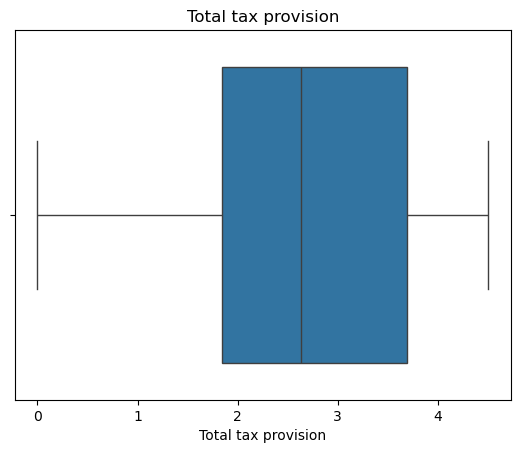

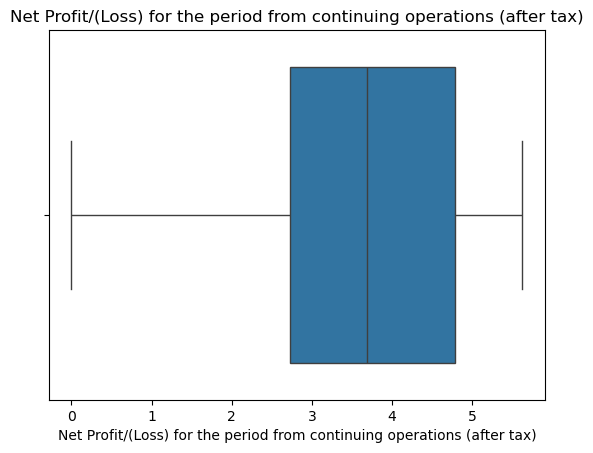

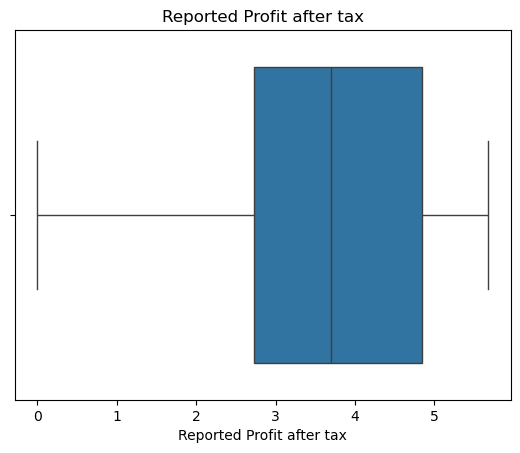

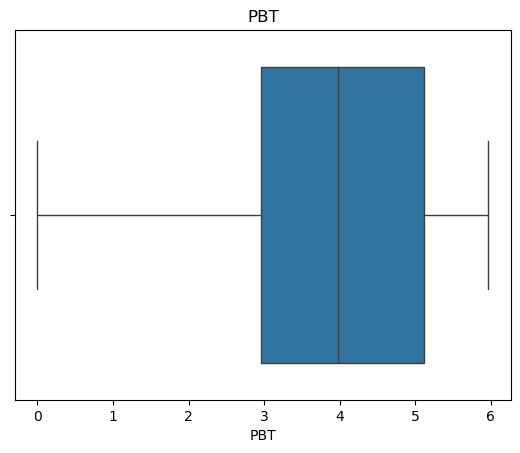

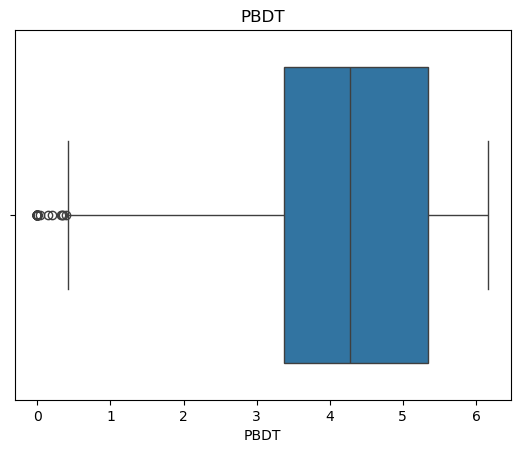

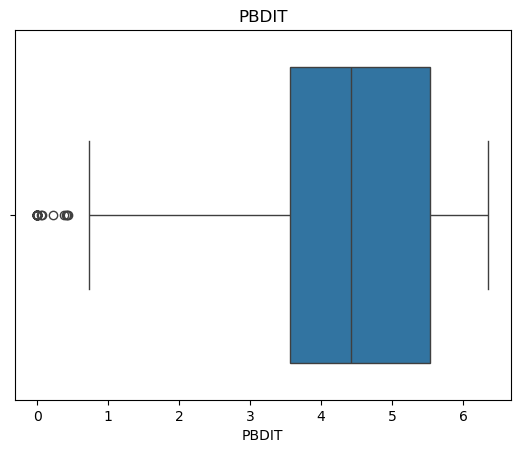

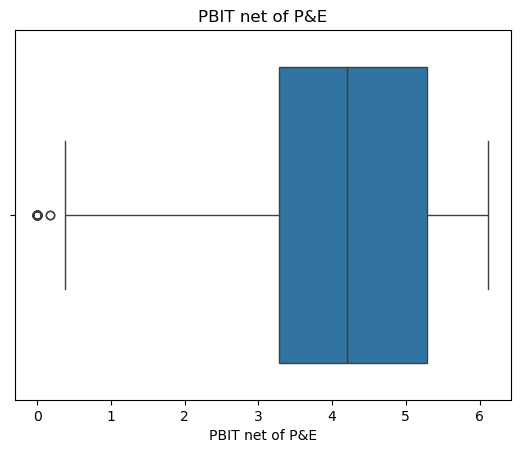

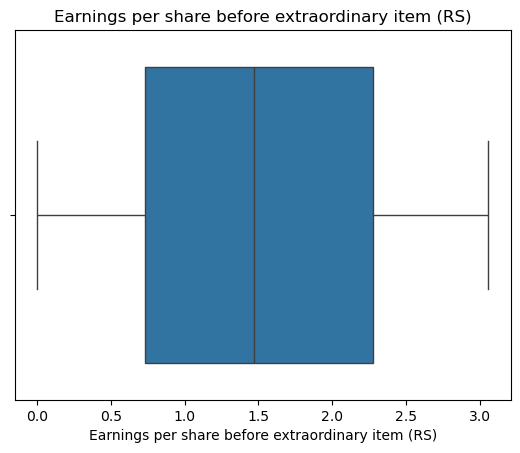

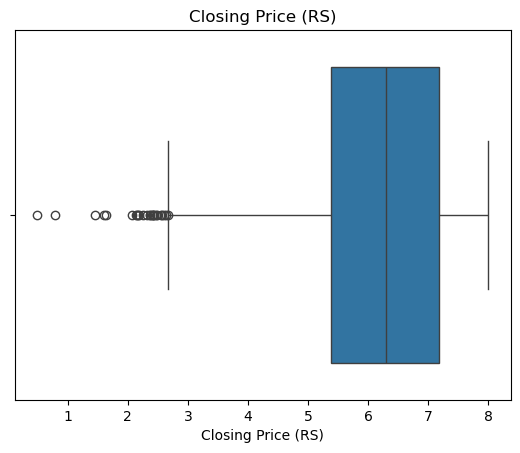

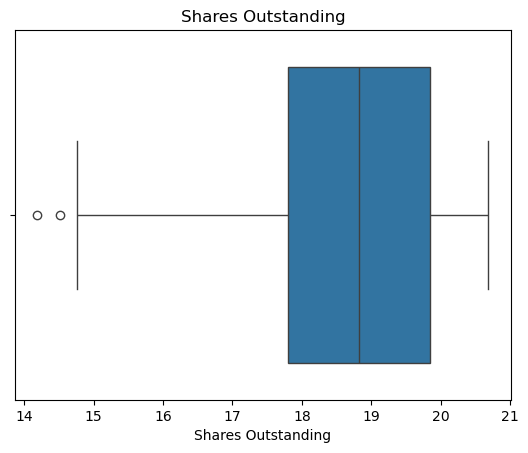

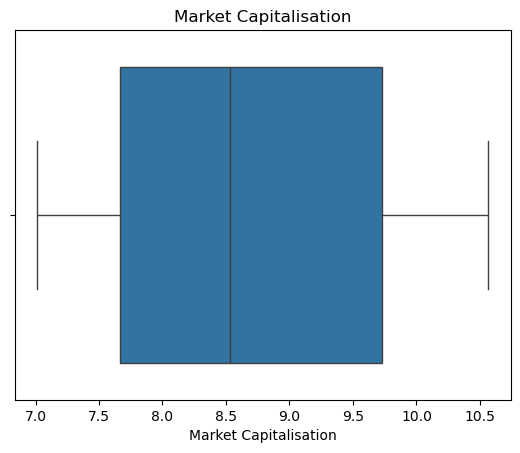

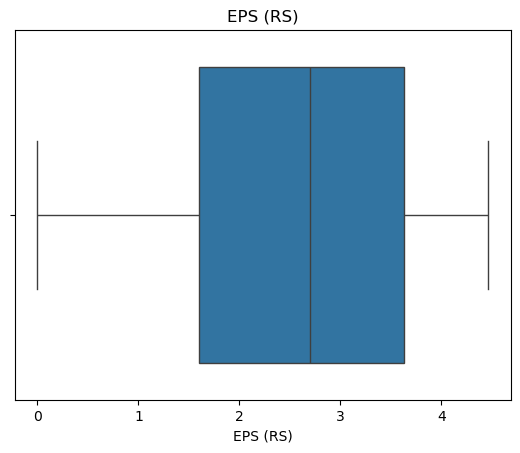

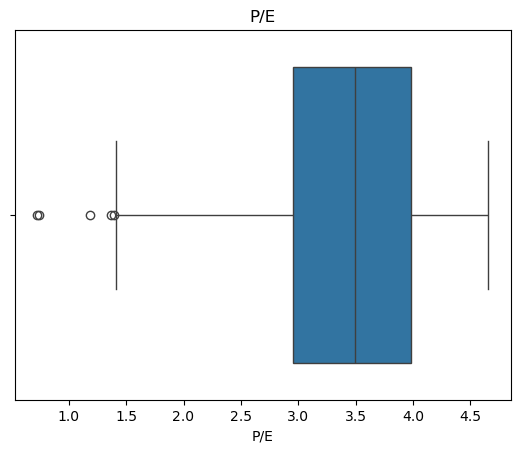

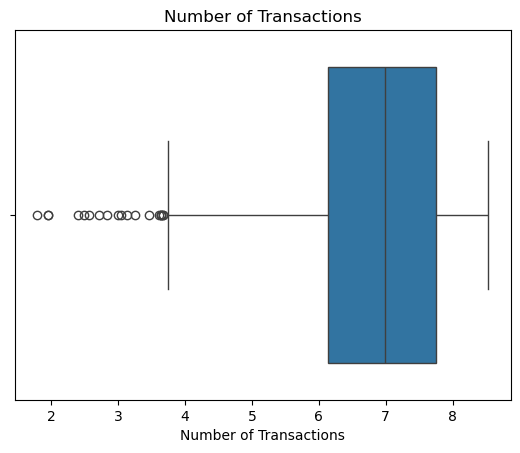

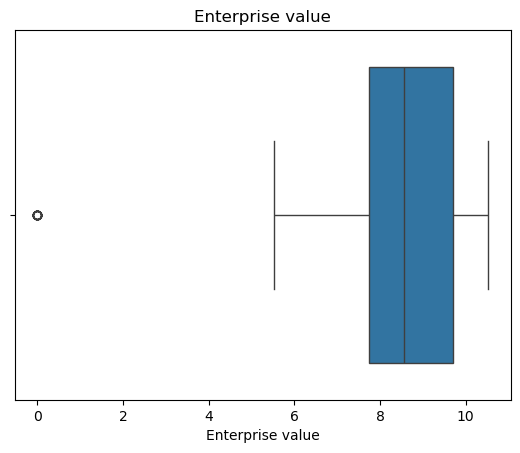

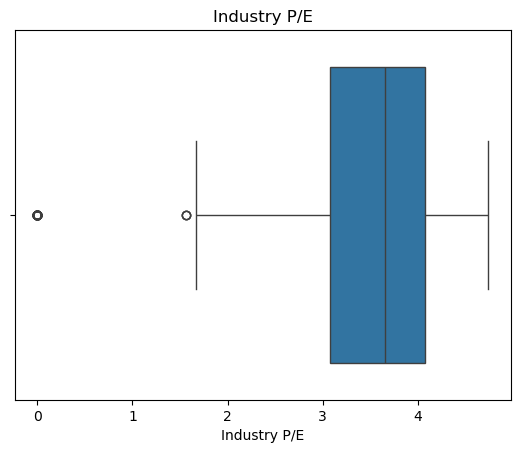

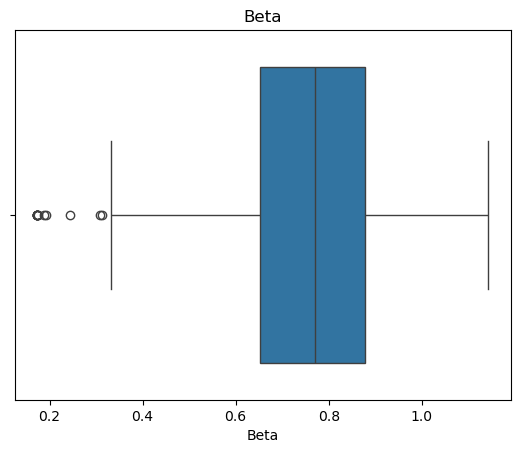

In [45]:
# Visualization Box plot
for col in num_cols:
    sns.boxplot(x=df_log_imputed[col])
    plt.title(col)
    plt.show()

Financial Ratio Computation

In [46]:
#Safe division helper (VERY IMPORTANT)
def safe_divide(a, b):
    return np.where((b == 0) | (b.isna()), np.nan, a / b)

In [49]:
#Profitability Ratios
# ==============================
# 3. Safe division function
# ==============================
def safe_divide(a, b):
    return np.where((b == 0) | (b.isna()), np.nan, a / b)

# ==============================
# 4. PROFITABILITY RATIOS
# ==============================

# EBITDA Margin
df["EBITDA_Margin"] = safe_divide(
    df["PBDT"], 
    df["Net sales"]
)

# Net Profit Margin
df["Net_Profit_Margin"] = safe_divide(
    df["Reported Profit after tax"],
    df["Net sales"]
)

# Return on Equity (ROE)
df["ROE"] = safe_divide(
    df["Reported Profit after tax"],
    df["Market Capitalisation"] / df["Closing Price (RS)"] * df["EPS (RS)"]
)

# Return on Assets (ROA)
df["ROA"] = safe_divide(
    df["Reported Profit after tax"],
    df["Enterprise value"]
)

# ==============================
# 5. GROWTH RATIOS
# ==============================

# Net Profit Growth (YoY)
df["Net_Profit_Growth"] = (
    df.groupby("Company Name")["Reported Profit after tax"]
      .pct_change()
)

# Sales Growth
df["Sales_Growth"] = (
    df.groupby("Company Name")["Net sales"]
      .pct_change()
)

# ==============================
# 6. LEVERAGE & SOLVENCY RATIOS
# ==============================

# Interest Coverage Ratio
df["Interest_Coverage"] = safe_divide(
    df["PBT"] + df["Interest expenses"],
    df["Interest expenses"]
)

# ==============================
# 7. EFFICIENCY RATIOS
# ==============================

# Asset Turnover
df["Asset_Turnover"] = safe_divide(
    df["Net sales"],
    df["Enterprise value"]
)

# ==============================
# 8. VALUATION RATIOS
# ==============================

# Price to Earnings (computed, not trusting raw P/E)
df["PE_Computed"] = safe_divide(
    df["Closing Price (RS)"],
    df["EPS (RS)"]
)

# Market Cap to Sales
df["MarketCap_to_Sales"] = safe_divide(
    df["Market Capitalisation"],
    df["Net sales"]
)

# EV to Sales
df["EV_to_Sales"] = safe_divide(
    df["Enterprise value"],
    df["Net sales"]
)

# ==============================
# 9. Keep only required columns
# ==============================
ratio_columns = [
    "EBITDA_Margin",
    "Net_Profit_Margin",
    "ROE",
    "ROA",
    "Net_Profit_Growth",
    "Sales_Growth",
    "Interest_Coverage",
    "Asset_Turnover",
    "PE_Computed",
    "MarketCap_to_Sales",
    "EV_to_Sales"
]

final_df = df[
    ["Company Name", "Industry group" ] + ratio_columns
]

# ==============================
# 10. Mild outlier handling (recommended)
# ==============================
for col in ratio_columns:
    final_df[col] = final_df[col].clip(
        final_df[col].quantile(0.01),
        final_df[col].quantile(0.99)
    )

# ==============================
# 11. Save to CSV
# ==============================
final_df.to_csv(
    "computed_financial_ratios.csv",
    index=False
)

print("✅ Financial ratios computed and saved as computed_financial_ratios.csv")

✅ Financial ratios computed and saved as computed_financial_ratios.csv


C:\Users\gunjan\AppData\Local\Temp\ipykernel_20056\2473658559.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col] = final_df[col].clip(
C:\Users\gunjan\AppData\Local\Temp\ipykernel_20056\2473658559.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col] = final_df[col].clip(
C:\Users\gunjan\AppData\Local\Temp\ipykernel_20056\2473658559.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu